# Deep Learning Report - LSTM for Time Series Prediction on Bike Usage Data (KielRegion Sprottenflotte)

> For reproducing this notebook with full training installing torch with cuda is reecommended. Runtime on CPU can be up to 3 hours and beyond.

> Full training will only be executed if the global variable below is set to True (`FORCE_RETRAIN = True`) otherwise saved weights from `resources/models` directory will be loaded to reproduce the notebook

In [1]:
# Setting this to "True" will cause full retraining of the all 15 model initializations, these will overwrite the model weights saved in "resources/models"
FORCE_RETRAIN = False

## 1. Task 1 - The Data

### Project Context

As outlined in the pitch, this project continues work on a bike availability prediction system for KielRegion's Sprottenflotte network. A previous iteration of this project (late 2024) attempted to train an LSTM for 5-hour-ahead predictions but struggled to outperform a naive persistence baseline (see resources 1). The key challenges identified were:

- Limited training data (only ~5 months available at the time)
- Network-wide prediction across stations with vastly different usage patterns
- High persistence in bike counts (most hours show zero change)

This report presents a refined approach addressing these limitations: focusing on central Kiel stations with similar behavior, using improved preprocessing with temporal completeness checks.

### Dataset Origin

This dataset was collected via an API of a data platform which the IT-serviceprovider ADDIX hosts for KielRegion, the organisation responsible for the bike service Sprottenflotte. The API access was acquired during a project cooperation with KielRegion in late 2024 and never revoked. Sprottenflotte hosts 194 bike rental stations over the wider metro area of Kiel and surrounding cities. The dataset contains the number of available bikes per hour combined with the weather situation at that hour at each station from 2024-06-17 to 2025-12-01.

### Suitability of the Dataset for the Task

The Sprottenflotte dataset is well-suited for this deep learning feasibility study for several reasons:

- **Operational relevance:** This is real production data from the exact network where any successful model would be deployed
- **Temporal depth:** With data now spanning June 2024 to December 2025 (~18 months), the model can learn seasonal patterns that were unavailable in the first project iteration

### Free Use of the Data

Even though no official license exists, to use and post the data acquired via the API was explicitly encouraged (also for private future projects) by our project management during the Application Project with KielRegion. Smaller versions of this dataset were uploaded under their permission and are still available on public GitHub repositories (see for example: https://github.com/Claas99/sprottenflotte_pred_tool/tree/main).

In [2]:
### Imports and general settings

# Import libraries
import pandas as pd
import numpy as np
import warnings
import torch
import torch.nn as nn
import torch.nn.init as init
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import pickle
import random
import os
import copy
import time


# Set max column display to None
pd.options.display.max_columns = None

# Filter warnings
warnings.filterwarnings('ignore')

# Reproducibility Seeds
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# For full CUDA reproducibility (if using GPU)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)         # random seed for current GPU
    torch.cuda.manual_seed_all(RANDOM_SEED)     # random seed for all GPUs if multiple
    torch.backends.cudnn.deterministic = True   # force cudnn to work deterministic
    torch.backends.cudnn.benchmark = False      # this feature adds speed but introduces randomness

# Read in the data
raw_data = pd.read_csv("data/bike_stations_all_2025_dl.csv")

# Display dataset
raw_data

,index,entityId,entityType,availableBikeNumber,totalSlotNumber,freeSlotNumber,station_name,maximum_capacity,latitude,longitude,subarea
0,2024-06-17T11:00:00.000+00:00,24367,BikeHireDockingStation,5.032787,30.0,25.000000,Anleger Dietrichsdorf,30,54.329611,10.178556,NaN
1,2024-06-17T12:00:00.000+00:00,24367,BikeHireDockingStation,6.762712,30.0,24.237288,Anleger Dietrichsdorf,30,54.329611,10.178556,NaN
2,2024-06-17T13:00:00.000+00:00,24367,BikeHireDockingStation,6.864407,30.0,24.000000,Anleger Dietrichsdorf,30,54.329611,10.178556,NaN
3,2024-06-17T14:00:00.000+00:00,24367,BikeHireDockingStation,5.846154,30.0,24.153846,Anleger Dietrichsdorf,30,54.329611,10.178556,NaN
4,2024-06-17T15:00:00.000+00:00,24367,BikeHireDockingStation,5.305556,30.0,24.694444,Anleger Dietrichsdorf,30,54.329611,10.178556,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2401661,2025-11-30T19:00:00.000+00:00,30434,BikeHireDockingStation,7.000000,18.0,11.000000,Felde Gemeindezentrum,18,54.299552,9.933817,NaN
2401662,2025-11-30T20:00:00.000+00:00,30434,BikeHireDockingStation,7.000000,18.0,11.000000,Felde Gemeindezentrum,18,54.299552,9.933817,NaN
2401663,2025-11-30T21:00:00.000+00:00,30434,BikeHireDockingStation,7.000000,18.0,11.000000,Felde Gemeindezentrum,18,54.299552,9.933817,NaN
2401664,2025-11-30T22:00:00.000+00:00,30434,BikeHireDockingStation,7.000000,18.0,11.000000,Felde Gemeindezentrum,18,54.299552,9.933817,NaN


### Feature Descriptions

> This DataFrame looks different from the one presented in the pitch slides. This is because the pitch showed a preprocessed dataset version of the first project iteration. After preprocessing our dataset will have a comparable structure to the pitch.

| Column | Description | Range / Values |
|--------|-------------|----------------|
| `index` | Timestamp of the observation (hourly) | 2024-06-17 to 2025-11-30 |
| `entityId` | Unique identifier for each bike station | 24367 – 30434 |
| `availableBikeNumber` | Number of bikes on average available at the station at the given hour | 0 – 69 |
| `totalSlotNumber` | Total number of docking slots at the station | 0 – 80 |
| `freeSlotNumber` | Number of empty slots available for returning bikes | 0 – 80 |
| `maximum_capacity` | Maximum capacity of the station | 6 – 50 |
| `latitude` | Geographic latitude of the station | 54.15 – 54.62°N |
| `longitude` | Geographic longitude of the station | 9.58 – 10.42°E |
| `subarea` | Subregion classification of the station | Currently empty (NaN) |
| `station_name` | Human-readable name of the station | e.g., "Anleger Dietrichsdorf", "Felde Gemeindezentrum" |

**Note on weather data:** In contrast to the original model development, this project does not include weather data. This is differently justified in the pitch (we are trying to sell our project to the customer). Really the problem is that for the extended timeframe the weather API returned 404 errors. In total 4 months of weather data were missing. Model training while excluding this time frame would be possible (simply create multiple sliding window datasets for where weather data exists and concatenate them before training) but following through the steps of preprocessing you will get the idea of why this would have added too much complexity to this project. 

## 2. Task 2 - Initial Data Analysis

Reproducibility: you set torch.manual_seed, but also set np.random.seed and (if using CUDA) torch.cuda.manual_seed_all + deterministic flags (only if you care).

### 2.1 Basic shape, size and datatypes

In [3]:
### Basic shape, size and datatypes
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401666 entries, 0 to 2401665
Data columns (total 11 columns):
 #   Column               Dtype  
---  ------               -----  
 0   index                object 
 1   entityId             int64  
 2   entityType           object 
 3   availableBikeNumber  float64
 4   totalSlotNumber      float64
 5   freeSlotNumber       float64
 6   station_name         object 
 7   maximum_capacity     int64  
 8   latitude             float64
 9   longitude            float64
 10  subarea              float64
dtypes: float64(6), int64(2), object(3)
memory usage: 201.6+ MB


- ~2.4 million rows × 11 columns
- Memory usage: ~200 MB
- Timestamp column (`index`) stored as string → requires datetime conversion
- Target variable not present → must be engineered during preprocessing

### 2.2 Missing value analysis

In [4]:
# check for NaN amount per column
nan_summary = pd.DataFrame({
    'nan_count': raw_data.isna().sum(),
    'nan_percentage': (raw_data.isna().sum() / len(raw_data) * 100).round(2)
})
nan_summary

,nan_count,nan_percentage
index,0,0.0
entityId,0,0.0
entityType,0,0.0
availableBikeNumber,0,0.0
totalSlotNumber,273707,11.4
freeSlotNumber,0,0.0
station_name,0,0.0
maximum_capacity,0,0.0
latitude,0,0.0
longitude,0,0.0


**Findings:**
- `totalSlotNumber`: 11.4% missing (273,707 rows)
- `subarea`: 100% missing (not populated)
- All other columns: Complete

**Action:** Both columns with significant NaN values are non-essential and will be dropped during preprocessing.

### 2.3 Statistical summary

In [5]:
# Describe raw data with adjusted formatting for better readability
raw_data.describe().apply(lambda x: x.map('{:.2f}'.format))

,entityId,availableBikeNumber,totalSlotNumber,freeSlotNumber,maximum_capacity,latitude,longitude,subarea
count,2401666.00,2401666.00,2127959.00,2401666.00,2401666.00,2401666.00,2401666.00,0.00
mean,26092.96,4.73,20.48,15.40,20.43,54.36,10.06,nan
std,2102.88,4.98,6.96,7.28,6.74,0.09,0.22,nan
min,24367.00,0.00,0.00,0.00,6.00,54.15,9.58,nan
25%,24416.00,1.00,15.00,10.05,15.00,54.31,9.84,nan
50%,24464.00,3.00,20.00,15.00,20.00,54.33,10.13,nan
75%,27451.00,7.00,25.00,19.87,25.00,54.40,10.20,nan
max,30434.00,69.23,80.00,80.00,50.00,54.62,10.42,nan


The dataset contains approximately 2.4 million records across 194 bike stations in Kiel. Key observations:

- Available bikes range from 0 to 69, with a mean of ~4.7 bikes per station and median of 3, indicating a right-skewed distribution
- Geographic coverage spans latitudes 54.15–54.62°N and longitudes 9.58–10.42°E, covering the greater Kiel area
- Station capacity varies from 6 to 50 slots, with a mean of ~20 slots per station.

### 2.4 Amount of time series data and station IDs

In [6]:
# Print out statistics
print(f"Individual Stations:    {raw_data['entityId'].nunique()}")
print(f"Time Range:  {raw_data['index'].min()} to {raw_data['index'].max()}")
print(f"Total Hours: {raw_data['index'].nunique()}")
print(f"Total Days:  {int(raw_data['index'].nunique()/24)}")

Individual Stations:    194
Time Range:  2024-06-17T11:00:00.000+00:00 to 2025-11-30T23:00:00.000+00:00
Total Hours: 12504
Total Days:  521


## 3. Task 3 - Preprocessing

In this section, we transform the raw API logs into a clean format suitable for LSTM training. To ensure valid time sequences and relevant spatial data, we implement the following steps:

1.  **Removing unused columns:** Not all columns provided by the API are needed for this experiment.
2.  **Spatial Filtering:** We restrict the dataset to the stations in "central" Kiel to prevent an overhang low-activity stations in the dataset (makes baseline too hard to beat).
3.  **Cyclical Features:** We encode timestamps into **sine and cosine values** to capture daily and weekly periodicity.
4.  **Data Continuity:** We isolate the **longest continuous time segment** (max gap length = 4 hours, gaps get interpolated) to allow for uninterrupted sequence learning.
5. **Target Creation:** We generate a supervised learning target by shifting bike availability **5 hours into the future** ($t+5h$).
6. **Stationarity:** We have to check if our data is stationary or not and if differencing needs to be applied.

### 3.1 Removing unnecessary columns
**Rationale:**
- Our further preorocessing only requires: `entityId`, `index` (timestamp), `availableBikeNumber`
- Location data (`latitude`, `longitude`) retained for station filtering
- Dropped columns: `totalSlotNumber`, `freeSlotNumber`, `maximum_capacity`, `subarea`, `entityType`, `station_name`

**Why drop these:**
- High NaN rates (`totalSlotNumber`: 11.4%, `subarea`: 100%)
- Dropped features not inherently useful for temporal prediction task

In [7]:
# Features to remove
drop_columns = ["totalSlotNumber", "freeSlotNumber", "maximum_capacity", "subarea", "entityType", "station_name"]

# Removing features
raw_data = raw_data.drop(columns=drop_columns)

raw_data

,index,entityId,availableBikeNumber,latitude,longitude
0,2024-06-17T11:00:00.000+00:00,24367,5.032787,54.329611,10.178556
1,2024-06-17T12:00:00.000+00:00,24367,6.762712,54.329611,10.178556
2,2024-06-17T13:00:00.000+00:00,24367,6.864407,54.329611,10.178556
3,2024-06-17T14:00:00.000+00:00,24367,5.846154,54.329611,10.178556
4,2024-06-17T15:00:00.000+00:00,24367,5.305556,54.329611,10.178556
...,...,...,...,...,...
2401661,2025-11-30T19:00:00.000+00:00,30434,7.000000,54.299552,9.933817
2401662,2025-11-30T20:00:00.000+00:00,30434,7.000000,54.299552,9.933817
2401663,2025-11-30T21:00:00.000+00:00,30434,7.000000,54.299552,9.933817
2401664,2025-11-30T22:00:00.000+00:00,30434,7.000000,54.299552,9.933817


- **Note on ` ìndex` column:** Our timestamps are called index. This is a bit inaccurate since they are not the actual index. Yet we will not change this because this is how it was returned by the API and worked on in the last project iteration and we don't want to confuse ourselves.

### 3.2 Removing stations outside of Kiel

**Rationale:**
- Stations within central Kiel behave more similarly
- Lower change rates outside of Kiel will bias the model strongly toward predicting no change (experience from the first project)
- Reduces model complexity and training time
- Improves prediction accuracy for core service area

**Method:**
- Define bounding box for central Kiel area
- Visualize selection using OpenStreetMap basemap
- Remove all records of staions outside the box from the dataset

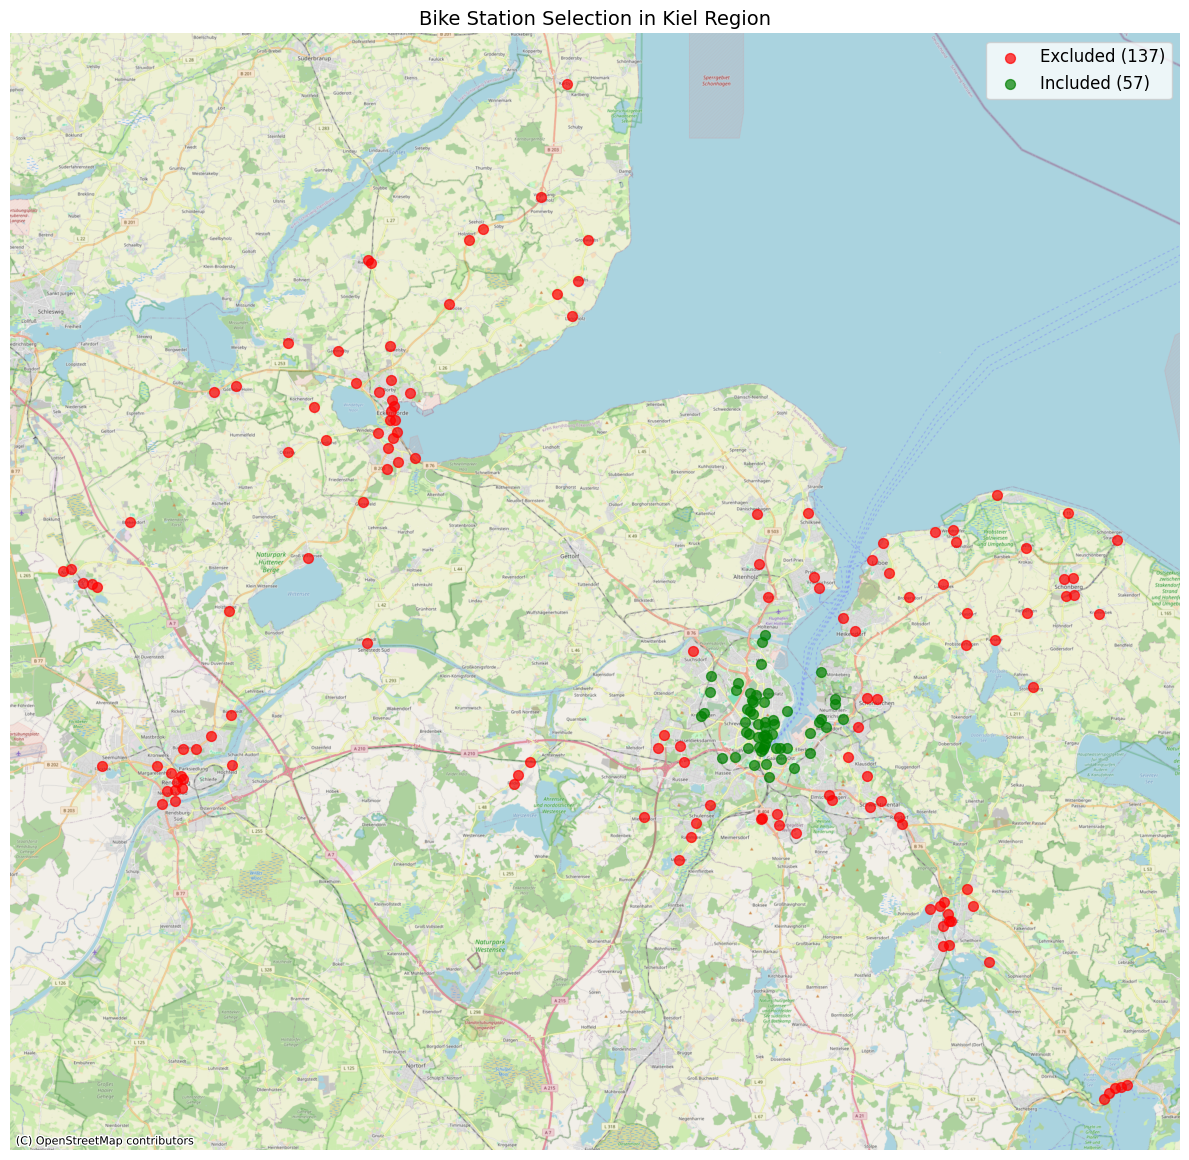

Total stations: 194
Included stations: 57
Excluded stations: 137


In [8]:
# Create GeoDataFrame from station coordinates
stations = raw_data.groupby('entityId').agg({
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

stations['geometry'] = stations.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
gdf_stations = gpd.GeoDataFrame(stations, geometry='geometry', crs='EPSG:4326')

# Define central Kiel bounding box
central_kiel = {
    'min_lat': 54.30,
    'max_lat': 54.37,
    'min_lon': 10.08,
    'max_lon': 10.20
}

# Filter for central Kiel stations
central_stations = gdf_stations[
    (gdf_stations['latitude'] >= central_kiel['min_lat']) &
    (gdf_stations['latitude'] <= central_kiel['max_lat']) &
    (gdf_stations['longitude'] >= central_kiel['min_lon']) &
    (gdf_stations['longitude'] <= central_kiel['max_lon'])
]

stations_to_keep = central_stations['entityId'].tolist()

# Create separate GeoDataFrames for plotting
gdf_excluded = gdf_stations[~gdf_stations['entityId'].isin(stations_to_keep)].copy()
gdf_included = gdf_stations[gdf_stations['entityId'].isin(stations_to_keep)].copy()

# Convert to Web Mercator for contextily
gdf_excluded = gdf_excluded.to_crs(epsg=3857)
gdf_included = gdf_included.to_crs(epsg=3857)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot excluded stations (red)
gdf_excluded.plot(ax=ax, color='red', markersize=50, alpha=0.7, label=f'Excluded ({len(gdf_excluded)})')

# Plot included stations (green)
gdf_included.plot(ax=ax, color='green', markersize=50, alpha=0.7, label=f'Included ({len(gdf_included)})')

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)

ax.set_title('Bike Station Selection in Kiel Region', fontsize=14)
ax.set_axis_off()
ax.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary
print(f"Total stations: {len(gdf_stations)}")
print(f"Included stations: {len(gdf_included)}")
print(f"Excluded stations: {len(gdf_excluded)}")

- Although Mönkeberg is not part of Kiel, its station is included as the simplest way to cover stations up to Kiel-Wik on the west shore. Some lower-traffic stations are acceptable, as they were also present in large amounts in the original project

In [9]:
# Filter the main dataframe to keep only selected stations
raw_data = raw_data[raw_data['entityId'].isin(stations_to_keep)].reset_index(drop=True)

print(f"Rows after filtering: {len(raw_data)}")
print(f"Remaining stations: {raw_data['entityId'].nunique()}")

Rows after filtering: 706241
Remaining stations: 57



**Result:**
- Reduced from 194 to 57 central stations
- Significant reduction in dataset size (from 2401666 rows to 706241 rows) while retaining important change patterns
- This will improve training time and likelyhood to predict a change in bike number
- Additionally removing a large amount of stations will make our filtering and interpolation at 3.4 easier

### 3.3 Datatype transformations and creating time features

**Datetime conversion:**
- Convert `index` from string to datetime format

**Cyclical time encoding:**
- Time-of-day encoded using sine/cosine transformations
- Preserves cyclical nature (23:00 is close to 00:00)
- Formula: `sin(2π × seconds_in_day / 86400)` and `cos(2π × seconds_in_day / 86400)`

**Day-of-year encoding:**
- Captures seasonal patterns
- Same sine/cosine approach for cyclical representation

**Why cyclical encoding:**
- Linear encoding (0-23 for hours) implies 23 is far from 0 (identical for time of year)
- Sine/cosine encoding correctly represents cyclical proximity

In [10]:
### Setting up day of year and time of day sin and cos 
# Got this idea here: https://www.youtube.com/watch?v=kGdbPnMCdOg&t=1828s


# Convert 'index' to datetime
raw_data['index'] = pd.to_datetime(raw_data['index'])

# Extract seconds in day and calculate sine/cosine transformations
day = 24 * 60 * 60  # Total seconds in a day
year = 365.2425 * day  # Approximate total seconds in a year

# Ensure that all datetime objects are tz-naive (prevents an error that was cause before)
raw_data['index'] = raw_data['index'].dt.tz_localize(None)

# Timestamp seconds (linear value for point in time)
raw_data['Seconds'] = raw_data['index'].map(pd.Timestamp.timestamp)

# Apply sine and cosine transformations
raw_data['day_sin'] = np.sin(raw_data['Seconds'] * (2* np.pi / day))
raw_data['day_cos'] = np.cos(raw_data['Seconds'] * (2 * np.pi / day))
raw_data['year_sin'] = np.sin(raw_data['Seconds'] * (2 * np.pi / year))
raw_data['year_cos'] = np.cos(raw_data['Seconds'] * (2 * np.pi / year))

# Drop temporary columns
raw_data.drop(columns=['Seconds'], inplace=True)

# Display result
raw_data

,index,entityId,availableBikeNumber,latitude,longitude,day_sin,day_cos,year_sin,year_cos
0,2024-06-17 11:00:00,24367,5.032787,54.329611,10.178556,2.588190e-01,-0.965926,0.242824,-0.970070
1,2024-06-17 12:00:00,24367,6.762712,54.329611,10.178556,9.948840e-12,-1.000000,0.242128,-0.970244
2,2024-06-17 13:00:00,24367,6.864407,54.329611,10.178556,-2.588190e-01,-0.965926,0.241433,-0.970418
3,2024-06-17 14:00:00,24367,5.846154,54.329611,10.178556,-5.000000e-01,-0.866025,0.240737,-0.970590
4,2024-06-17 15:00:00,24367,5.305556,54.329611,10.178556,-7.071068e-01,-0.707107,0.240042,-0.970763
...,...,...,...,...,...,...,...,...,...
706236,2025-11-30 19:00:00,30146,22.000000,54.317114,10.133099,-9.659258e-01,0.258819,-0.505227,0.862987
706237,2025-11-30 20:00:00,30146,21.866667,54.317114,10.133099,-8.660254e-01,0.500000,-0.504608,0.863348
706238,2025-11-30 21:00:00,30146,20.800000,54.317114,10.133099,-7.071068e-01,0.707107,-0.503989,0.863710
706239,2025-11-30 22:00:00,30146,19.116667,54.317114,10.133099,-5.000000e-01,0.866025,-0.503370,0.864071


- Resulting dataframe has now 4 new columns representing the time. It is now redundant information but we will keep index in our DataFrame because it is needed for further preprocessing and dataloading logic.

### 3.4 Isolate longest continuous time segment

Something that was never considered in the first project interation is that our timestamps are not neccessarily gap free. These gaps will not show as NaN since the behaviour of the API is not to produce a NaN record but to return the next available record. 
To prepare the raw data for sliding-window LSTM training, we transform it into a consistent, gap-free hourly time series through four key steps:

- Investigate how many hours are missing per station (individual and network wide)
- Filter for the longest timeframe where no network wide hour gaps longer than 5 hours exist
- Filter out stations withing this timeframe with longer than 5 hour individual hour gaps 
- Interpolate all remaining hour gaps

#### 3.4.1 Visual missing Hours Analysis
This diagnostic visualizes how many hours of data are missing for each station and distinguishes between two types of missingness:

**Network-Wide Missing Hours**

These are hours where *no station in the entire network* reported any data. Such gaps likely indicate system-level outages (e.g., API downtime, server maintenance) rather than issues with individual stations. All stations are equally affected by these hours.

**Station-Specific Missing Hours**

These are hours where a particular station failed to report while other stations did. This could indicate local sensor issues, station maintenance, or connectivity problems at specific locations.

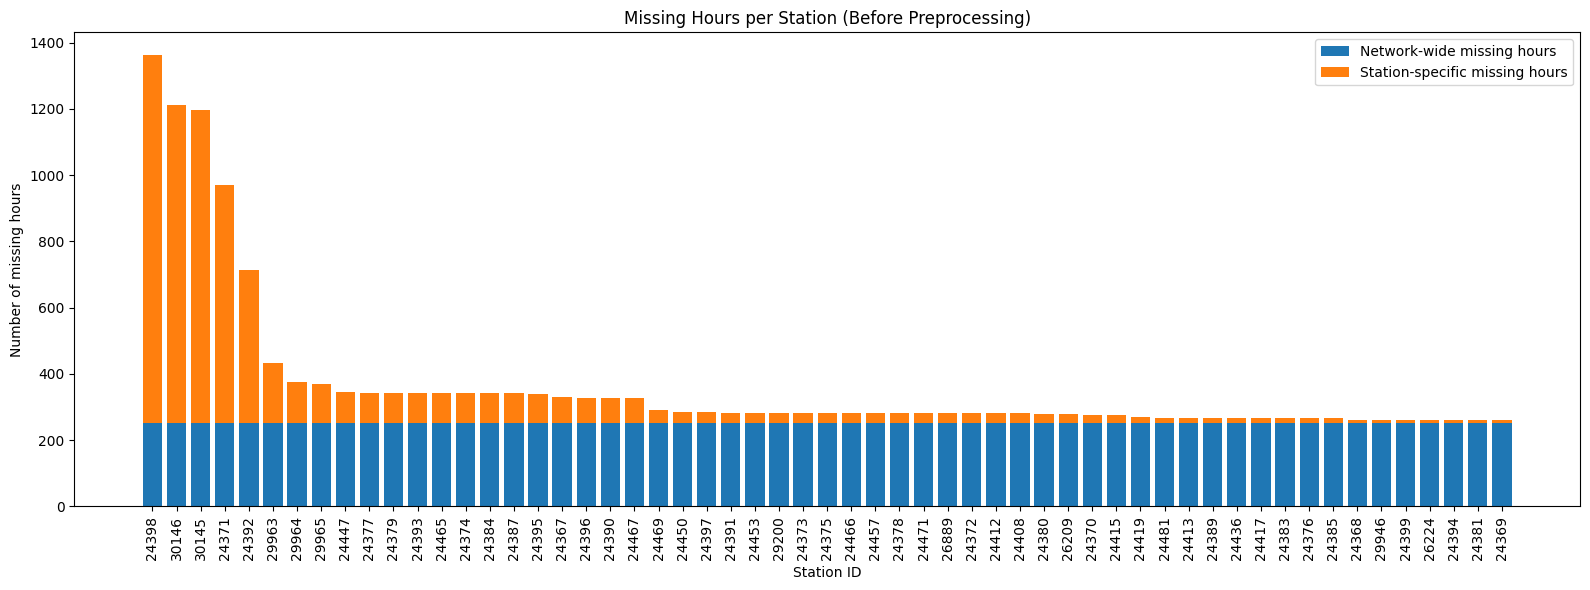

In [11]:
### Missing hours per station (station-specific vs network-wide)

# Prepare hourly grid
df_diag = raw_data.copy()
df_diag["index"] = pd.to_datetime(df_diag["index"])
df_diag["hour"] = df_diag["index"].dt.floor("h")

all_hours = pd.date_range(df_diag["hour"].min(), df_diag["hour"].max(), freq="h")
n_total_hours = len(all_hours)

# Count stations reporting per hour
stations_per_hour = df_diag.groupby("hour")["entityId"].nunique().reindex(all_hours, fill_value=0)
n_global_missing = (stations_per_hour == 0).sum()

# Compute observed hours per station using pivot (vectorized)
# Create presence matrix: stations x hours
presence = df_diag.groupby(["entityId", "hour"]).size().unstack(fill_value=0)
presence = (presence.reindex(columns=all_hours, fill_value=0) > 0).astype(int)

# Count observed hours per station
observed_counts = presence.sum(axis=1)

# Total missing = total hours - observed
total_missing = n_total_hours - observed_counts

# Global missing is the same for all stations
global_missing = pd.Series(n_global_missing, index=presence.index)

# Station-specific missing = total missing - global missing
station_missing = total_missing - global_missing

# Build DataFrame
missing_df = pd.DataFrame({
    "entityId": presence.index,
    "global_missing_hours": global_missing.values,
    "station_missing_hours": station_missing.values,
    "total_missing_hours": total_missing.values
}).sort_values("total_missing_hours", ascending=False).reset_index(drop=True)

# Plot: stacked bar chart
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(missing_df))
ax.bar(x, missing_df["global_missing_hours"], label="Network-wide missing hours")
ax.bar(x, missing_df["station_missing_hours"], bottom=missing_df["global_missing_hours"], 
       label="Station-specific missing hours")

ax.set_xlabel("Station ID")
ax.set_ylabel("Number of missing hours")
ax.set_title("Missing Hours per Station (Before Preprocessing)")
ax.set_xticks(x)
ax.set_xticklabels(missing_df["entityId"].astype(str), rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

- It has to be considered that the code to request the data from the API generated gaps in the timeframe by not finishing up the timeframe for one station before timing out and then moving to the next station when requesting again. Looking at the majority of missing hours being not station specific (network wide), the data rather seems not available from the API due to network outages.

#### 3.4.2 Remove unsued time sequences and interpolate remaining time gaps

In this preprocessing step, we transform the raw bike-station data into a **clean, regular hourly time series** that is suitable for training an LSTM with sliding windows.

**Step 1: Global Outage Detection and Timeline Segmentation**

First, all observations are aligned to an **hourly grid**, and duplicate measurements for the same station and hour are removed so that each station has at most one value per hour. This creates a consistent temporal resolution across the dataset.

Next, the data is analyzed at the **system level** to detect *global outages*—hours in which no station reports any data at all. If such outages last longer than a predefined threshold (`MAX_GAP_HOURS`), they are treated as hard breaks in the timeline. The full time range is therefore split into **continuous segments**, and one segment (the longest) is selected to ensure temporal continuity.

**Step 2: Station-Level Gap Analysis**

Within the selected segment, the focus shifts to the **station level**. For each station, the observed data is compared against the expected hourly timeline to identify missing hours and continuous missing intervals. Stations that contain gaps longer than `MAX_GAP_HOURS` are removed, as these gaps cannot be safely interpolated and would break sliding-window construction for the LSTM.

**Step 3: Reindexing and Interpolation**

For the remaining stations, the data is **reindexed so that each station has exactly one row per hour** in the selected segment. This explicitly introduces `NaN` values where data is missing. Short gaps (up to `MAX_GAP_HOURS`) are then filled using **time-based interpolation**, while longer gaps remain unfilled by design. In addition, a **mask feature** is created to mark which values were interpolated, allowing us to verify if everything worked as intended afterwards.

> Note on `MAX_GAP_HOURS`: This was set to 4 because our time prediction horizon is t+5 and like this we prevent the model to predict an interpolated t+5 based on an interpolated t+0.

In [12]:
### Perform  Segmentation, station removal and gap interpolation
# Why is there config options: My original plan was to work with multiple segments that get processed by the dataloader seperately, but there was no time to incorporate this complexity into the project
# Due to time management issues this code cell was not adjusted backwards when the notebook was finished

# CONFIG
MAX_GAP_HOURS = 4
PICK_SEGMENT = "longest"
INTERP_METHOD = "time"

df = raw_data.copy()
df["index"] = pd.to_datetime(df["index"])
df["hour"] = df["index"].dt.floor("H")

# Remove duplicates
df = df.sort_values("hour").drop_duplicates(["entityId", "hour"], keep="last")

stations_all = df["entityId"].unique()
all_hours = pd.date_range(df["hour"].min(), df["hour"].max(), freq="H")

### Step 1: Global outage detection and segmentation
stations_per_hour = df.groupby("hour")["entityId"].nunique().reindex(all_hours, fill_value=0)
global_missing_mask = stations_per_hour == 0

# Find break points using diff on the boolean mask
if global_missing_mask.any():
    # Convert to numeric for efficient run-length detection
    missing_changes = global_missing_mask.astype(int).diff().fillna(0)
    run_starts = all_hours[missing_changes == 1]
    run_ends = all_hours[missing_changes == -1]
    
    # Handle edge cases
    if global_missing_mask.iloc[0]:
        run_starts = run_starts.insert(0, all_hours[0])
    if global_missing_mask.iloc[-1]:
        run_ends = run_ends.append(pd.DatetimeIndex([all_hours[-1]]))
    
    # Calculate run lengths and find break points
    run_lengths = ((run_ends - run_starts) / pd.Timedelta(hours=1)).astype(int) + 1
    break_mask = run_lengths > MAX_GAP_HOURS
    break_points = list(zip(run_starts[break_mask], run_ends[break_mask]))
else:
    break_points = []

# Build segments
if not break_points:
    segments = [(all_hours.min(), all_hours.max())]
else:
    segments = []
    seg_start = all_hours.min()
    for bstart, bend in sorted(break_points):
        seg_end = bstart - pd.Timedelta(hours=1)
        if seg_end >= seg_start:
            segments.append((seg_start, seg_end))
        seg_start = bend + pd.Timedelta(hours=1)
    if seg_start <= all_hours.max():
        segments.append((seg_start, all_hours.max()))

# Choose segment
seg_lengths = [(s[1] - s[0]).total_seconds() / 3600 + 1 for s in segments]
SEG_START, SEG_END = segments[np.argmax(seg_lengths)] if PICK_SEGMENT == "longest" else segments[0]
print(f"Chosen segment: {SEG_START} → {SEG_END} ({int(max(seg_lengths))} hours)")

# Crop to segment
df_seg = df.query("@SEG_START <= hour <= @SEG_END").copy()
hours_seg = pd.date_range(SEG_START, SEG_END, freq="H")


### Step 2: Station-level missing runs (vectorized)

# Pivot to station x hour matrix - much faster than iteration
pivot = df_seg.pivot_table(index="hour", columns="entityId", values="availableBikeNumber", aggfunc="first")
pivot = pivot.reindex(hours_seg)

# Calculate max consecutive NaNs per station using vectorized approach
def max_consecutive_nans(series):
    isna = series.isna()
    cumsum = (~isna).cumsum()
    counts = isna.groupby(cumsum).cumsum()
    return counts.max() if counts.max() > 0 else 0

max_gaps = pivot.apply(max_consecutive_nans)
good_stations = max_gaps[max_gaps <= MAX_GAP_HOURS].index.tolist()

print(f"Stations in segment: {pivot.shape[1]}")
print(f"Stations kept (max_gap <= {MAX_GAP_HOURS}): {len(good_stations)}")

df_keep = df_seg[df_seg["entityId"].isin(good_stations)].copy()


### Step 3: Reindex and interpolate (vectorized via pivot)
numeric_cols = df_keep.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "entityId"]

# Process using pivot tables for each numeric column
panel_list = []

for station_id in good_stations:
    station_df = df_keep[df_keep["entityId"] == station_id].set_index("hour").reindex(hours_seg)
    
    # Fill entityId
    station_df["entityId"] = station_id
    
    # Create mask
    if "availableBikeNumber" in station_df.columns:
        station_df["mask_availableBikeNumber"] = station_df["availableBikeNumber"].isna().astype(np.int8)
    
    # Interpolate
    station_df[numeric_cols] = station_df[numeric_cols].interpolate(
        method=INTERP_METHOD, limit=MAX_GAP_HOURS, limit_direction="both"
    )
    
    panel_list.append(station_df.reset_index().rename(columns={"index": "hour"}))

# Concatenate once at the end (much faster than repeated appends)
raw_data = pd.concat(panel_list, ignore_index=True)

# Check if there are remaining NaNs
if "availableBikeNumber" in raw_data.columns:
    remaining = raw_data.groupby("entityId")["availableBikeNumber"].apply(lambda x: x.isna().sum())
    print("Remaining NaN list (sorted) head:")
    print(remaining.sort_values(ascending=False).head(3))

Chosen segment: 2025-06-17 08:00:00 → 2025-11-30 23:00:00 (4000 hours)
Stations in segment: 57
Stations kept (max_gap <= 4): 54
Remaining NaN list (sorted) head:
entityId
24367    0
24467    0
24413    0
Name: availableBikeNumber, dtype: int64


- We now perform some validation checks if the transformation went as intended

How many values were interpolated?

In [13]:
raw_data.mask_availableBikeNumber.value_counts()

mask_availableBikeNumber
0    215838
1       162
Name: count, dtype: int64

In [14]:
# looking at availableBikeNumber we see that the interpolation worked as intended 
raw_data.loc[raw_data.index[raw_data["mask_availableBikeNumber"] == 1][0] - 4 :
             raw_data.index[raw_data["mask_availableBikeNumber"] == 1][0] + 5]

,level_0,hour,entityId,availableBikeNumber,latitude,longitude,day_sin,day_cos,year_sin,year_cos,mask_availableBikeNumber
2398,2025-09-25 06:00:00,2025-09-25 06:00:00,24367,13.400000,54.329611,10.178556,1.000000,2.177423e-12,-0.994643,-0.103365,0
2399,2025-09-25 07:00:00,2025-09-25 07:00:00,24367,13.000000,54.329611,10.178556,0.965926,-2.588190e-01,-0.994717,-0.102652,0
2400,2025-09-25 08:00:00,2025-09-25 08:00:00,24367,13.000000,54.329611,10.178556,0.866025,-5.000000e-01,-0.994791,-0.101939,0
2401,2025-09-25 09:00:00,2025-09-25 09:00:00,24367,13.000000,54.329611,10.178556,0.707107,-7.071068e-01,-0.994863,-0.101226,0
2402,2025-09-25 10:00:00,NaT,24367,12.500000,54.329611,10.178556,0.465625,-7.718115e-01,-0.994935,-0.100513,1
2403,2025-09-25 11:00:00,NaT,24367,12.000000,54.329611,10.178556,0.224144,-8.365163e-01,-0.995007,-0.099800,1
2404,2025-09-25 12:00:00,NaT,24367,11.500000,54.329611,10.178556,-0.017338,-9.012211e-01,-0.995078,-0.099086,1
2405,2025-09-25 13:00:00,2025-09-25 13:00:00,24367,11.000000,54.329611,10.178556,-0.258819,-9.659258e-01,-0.995150,-0.098373,0
2406,2025-09-25 14:00:00,2025-09-25 14:00:00,24367,11.000000,54.329611,10.178556,-0.500000,-8.660254e-01,-0.995220,-0.097660,0
2407,2025-09-25 15:00:00,2025-09-25 15:00:00,24367,10.066667,54.329611,10.178556,-0.707107,-7.071068e-01,-0.995290,-0.096946,0


Has every station the same amount of rows now?

In [15]:
# If this is True all value counts have the equal value
raw_data.entityId.value_counts().nunique() == 1

True

In [16]:
# Clean up column names to maintain consistency
raw_data = raw_data.rename(columns={'level_0': 'index'})
raw_data = raw_data.drop(columns=['hour', 'mask_availableBikeNumber'])

# Ensure index is datetime
raw_data['index'] = pd.to_datetime(raw_data['index'])

- The preprocessing logic worked as intended.
- The final dataset contains 54 stations with a continuous segment of 4,000 hours (2025-06-17 to 2025-11-30).
- This provides significantly less time series data than anticipated in the project pitch and is comparable to the first project iteration.
- The reduction is mainly due to an unexpectedly high number of network-wide outages and missing individual hours.
- Despite this limitation, the project remains promising due to improved data completeness and the revised model architecture.


### 3.5 Creating target feature (available bikenumber t+5)

**Approach:**
- Target = `availableBikeNumber` shifted 5 hours into the future per station

**Implementation:**
- Sort by `entityId` and `index` to ensure correct temporal order (technically redundant but to make sure)
- Use `groupby().shift(-5)` to shift within each station
- Results in 5 NaN values per station (last 5 hours have no future data)

In [17]:
# Sort by station and time to ensure correct shifting
raw_data = raw_data.sort_values(['entityId', 'index']).reset_index(drop=True)

# Create target: availableBikeNumber 5 hours ahead per station
raw_data['target_5h'] = raw_data.groupby('entityId')['availableBikeNumber'].shift(-5)

# We can validate the successful target_creation by comparing target_5h of row 0 to availableBikeNumber of row 5 and so on
raw_data.head(10)

,index,entityId,availableBikeNumber,latitude,longitude,day_sin,day_cos,year_sin,year_cos,target_5h
0,2025-06-17 08:00:00,24367,1.983333,54.329611,10.178556,8.660254e-01,-0.500000,0.248952,-0.968516,2.000000
1,2025-06-17 09:00:00,24367,1.000000,54.329611,10.178556,7.071068e-01,-0.707107,0.248257,-0.968694,2.133333
2,2025-06-17 10:00:00,24367,1.450000,54.329611,10.178556,5.000000e-01,-0.866025,0.247563,-0.968872,4.000000
3,2025-06-17 11:00:00,24367,2.000000,54.329611,10.178556,2.588190e-01,-0.965926,0.246869,-0.969049,4.633333
4,2025-06-17 12:00:00,24367,2.000000,54.329611,10.178556,1.258909e-11,-1.000000,0.246174,-0.969226,2.933333
5,2025-06-17 13:00:00,24367,2.000000,54.329611,10.178556,-2.588190e-01,-0.965926,0.245479,-0.969402,4.000000
6,2025-06-17 14:00:00,24367,2.133333,54.329611,10.178556,-5.000000e-01,-0.866025,0.244784,-0.969578,4.100000
7,2025-06-17 15:00:00,24367,4.000000,54.329611,10.178556,-7.071068e-01,-0.707107,0.244089,-0.969753,5.000000
8,2025-06-17 16:00:00,24367,4.633333,54.329611,10.178556,-8.660254e-01,-0.500000,0.243394,-0.969928,5.000000
9,2025-06-17 17:00:00,24367,2.933333,54.329611,10.178556,-9.659258e-01,-0.258819,0.242699,-0.970102,5.000000


In [18]:
# Showing the last values before NaN removal
raw_data.tail(7)

,index,entityId,availableBikeNumber,latitude,longitude,day_sin,day_cos,year_sin,year_cos,target_5h
215993,2025-11-30 17:00:00,30146,22.000000,54.317114,10.133099,-0.965926,-2.588190e-01,-0.506463,0.862261,19.116667
215994,2025-11-30 18:00:00,30146,22.000000,54.317114,10.133099,-1.000000,-8.695171e-14,-0.505845,0.862624,17.783333
215995,2025-11-30 19:00:00,30146,22.000000,54.317114,10.133099,-0.965926,2.588190e-01,-0.505227,0.862987,NaN
215996,2025-11-30 20:00:00,30146,21.866667,54.317114,10.133099,-0.866025,5.000000e-01,-0.504608,0.863348,NaN
215997,2025-11-30 21:00:00,30146,20.800000,54.317114,10.133099,-0.707107,7.071068e-01,-0.503989,0.863710,NaN
215998,2025-11-30 22:00:00,30146,19.116667,54.317114,10.133099,-0.500000,8.660254e-01,-0.503370,0.864071,NaN
215999,2025-11-30 23:00:00,30146,17.783333,54.317114,10.133099,-0.258819,9.659258e-01,-0.502751,0.864432,NaN


- We expect 5 nan target rows per entity_ID, so we can quickly confirm if everything went according to plan
- The DataFrame before ended at at 23:00:00, after removing nan values it ends at the same EntityID at 18:00:00 (5 hours earlier) confirming successful removal of nan value rows.

In [19]:
# Check how many NaN values were created
print(f"NaN values in target: {raw_data['target_5h'].isna().sum()}")
print(f"Expected: {raw_data['entityId'].nunique() * 5}")  # 5 per station

# Drop rows without target
raw_data = raw_data.dropna(subset=['target_5h'])

raw_data

NaN values in target: 270
Expected: 270


,index,entityId,availableBikeNumber,latitude,longitude,day_sin,day_cos,year_sin,year_cos,target_5h
0,2025-06-17 08:00:00,24367,1.983333,54.329611,10.178556,8.660254e-01,-5.000000e-01,0.248952,-0.968516,2.000000
1,2025-06-17 09:00:00,24367,1.000000,54.329611,10.178556,7.071068e-01,-7.071068e-01,0.248257,-0.968694,2.133333
2,2025-06-17 10:00:00,24367,1.450000,54.329611,10.178556,5.000000e-01,-8.660254e-01,0.247563,-0.968872,4.000000
3,2025-06-17 11:00:00,24367,2.000000,54.329611,10.178556,2.588190e-01,-9.659258e-01,0.246869,-0.969049,4.633333
4,2025-06-17 12:00:00,24367,2.000000,54.329611,10.178556,1.258909e-11,-1.000000e+00,0.246174,-0.969226,2.933333
...,...,...,...,...,...,...,...,...,...,...
215990,2025-11-30 14:00:00,30146,21.000000,54.317114,10.133099,-5.000000e-01,-8.660254e-01,-0.508316,0.861170,22.000000
215991,2025-11-30 15:00:00,30146,21.466667,54.317114,10.133099,-7.071068e-01,-7.071068e-01,-0.507699,0.861534,21.866667
215992,2025-11-30 16:00:00,30146,22.000000,54.317114,10.133099,-8.660254e-01,-5.000000e-01,-0.507081,0.861898,20.800000
215993,2025-11-30 17:00:00,30146,22.000000,54.317114,10.133099,-9.659258e-01,-2.588190e-01,-0.506463,0.862261,19.116667


### 3.6 Checking and handling stationarity

The data is in a good condition for our experiments, but before moving on we need to check for staionarity (no differencing will be necessary)

**Why it matters:**
- Stationary data has constant mean and variance over time
- LSTMs can handle some non-stationarity, but stable patterns improve learning
- Non-stationary data may cause poor generalization

**Test method:**

- **Augmented Dickey-Fuller (ADF) test** - Statistical test for unit root
   - H0: Series has unit root (non-stationary)
   - H1: Series is stationary
   - p-value < 0.05 → reject H0 → stationary

In [20]:
### Test stationarity across multiple stations
def test_stationarity(series):
    """Run ADF test and return p-value."""
    result = adfuller(series.dropna())
    return result[1]  # p-value

# Test a sample of stations
station_ids = raw_data['entityId'].unique()
stationarity_results = []

for station_id in station_ids:
    station_data = raw_data[raw_data['entityId'] == station_id]['availableBikeNumber']
    p_value = test_stationarity(station_data)
    stationarity_results.append({
        'entityId': station_id,
        'p_value': p_value,
        'stationary': p_value < 0.05
    })

results_df = pd.DataFrame(stationarity_results)
print(f"Stationary stations: {results_df['stationary'].sum()} / {len(results_df)}")
print(f"Non-stationary stations: {(~results_df['stationary']).sum()} / {len(results_df)}")
results_df

Stationary stations: 53 / 54
Non-stationary stations: 1 / 54


,entityId,p_value,stationary
0,24367,1.569249e-02,True
1,24368,6.120024e-09,True
2,24369,4.712968e-12,True
3,24370,3.198386e-08,True
4,24372,1.255521e-05,True
5,24373,0.000000e+00,True
6,24374,2.337126e-08,True
7,24375,4.069677e-04,True
8,24376,3.788092e-15,True
9,24377,5.524571e-06,True


- All stations except one seem to behave stationary (was to be ecxpected by station nature, no upward/downward trend like in stocks etc. possible). We do not need to apply differencing to work with the data.

 > **Note:** Even if data was showing a bit more non-stationarity, LSTMs are relatively robust due to their ability to learn temporal dependencies. Non-stationarity is more problematic for traditional statistical models (e.g. ARIMA).

In [21]:
# Naming the final preprocessed dataset
data = raw_data.copy()

## 4. Task 4 - Exploratory Data Analysis

- Preprocessing already added a lot of complexity to this report, so the EDA will be kept very simplistic and focussed.

- **Objective:** Investigate the "Zero-Gap" dataset to validate the feasibility of the 5-hour prediction task and identify key patterns for the Deep Learning model.

### 4.1 Network Stability (Hour-to-Hour Flux Analysis)

**How much does the target variable actually change?**
- We analyze the distribution of absolute hour-to-hour changes in bike availability across all stations, binned at 0.5-bike resolution for granularity.
- If bike availability rarely changes hour-to-hour, a naive "predict no change" baseline will be nearly unbeatable. 
- if there's significant flux, a model has the opportunity to learn patterns that outperform simple persistence.

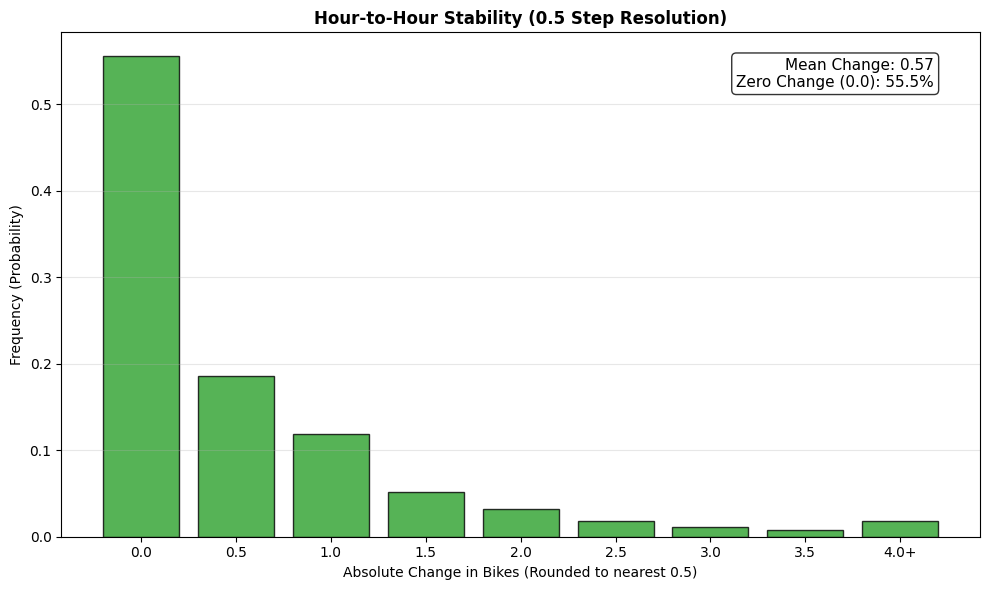

In [22]:
# Calculate absolute change (floats)
data['hourly_change'] = data.groupby('entityId')['availableBikeNumber'].diff().abs()

# Round to the nearest 0.5
data['flux_bin'] = (data['hourly_change'] * 2).round() / 2

# Clip the upper tail for readability
upper_limit = 4.0
data['flux_bin'] = data['flux_bin'].clip(upper=upper_limit)

# Calculate frequencies
change_counts = data['flux_bin'].value_counts(normalize=True).sort_index()

# Create labels (ensure all 0.5 steps are present up to the limit)
expected_steps = np.arange(0, upper_limit + 0.5, 0.5)
change_counts = change_counts.reindex(expected_steps, fill_value=0)

bucket_labels = [str(x) for x in expected_steps]
bucket_labels[-1] += "+"
bucket_values = change_counts.values

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(bucket_labels, bucket_values, color='#2ca02c', edgecolor='black', alpha=0.8)
ax.set_title('Hour-to-Hour Stability (0.5 Step Resolution)', fontsize=12, fontweight='bold')
ax.set_xlabel('Absolute Change in Bikes (Rounded to nearest 0.5)')
ax.set_ylabel('Frequency (Probability)')
ax.grid(axis='y', alpha=0.3)

# Add text stats
zero_change_pct = bucket_values[0] * 100
mean_change = data['hourly_change'].mean()
stats_text = f"Mean Change: {mean_change:.2f}\nZero Change (0.0): {zero_change_pct:.1f}%"

ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Clean up
data.drop(columns=['hourly_change', 'flux_bin'], inplace=True, errors='ignore')

The flux analysis reveals that approximately 55.5% of hourly observations show zero or minimal change (< 0.5 bikes). The mean absolute change is  0.57 bikes per hour.

This confirms that bike availability is **highly persistent**—most hours, nothing changes. This has two implications:

1. **Challenge**: The naive persistence baseline will be strong, as "predict no change" is correct most of the time.
2. **Opportunity**: The remaining 44.5% of hours *do* show movement. If the LSTM can learn *when* changes occur (rush hours, weekends), it can outperform the baseline on those critical predictions.

### 4.2 Prediction Feasibility (Autocorrelation Decay)

- Before committing to a 5-hour prediction horizon, it should be verified that current bike availability contains useful information about availability 5 hours later.
- **Autocorrelation** measures how correlated a time series is with lagged versions of itself. High autocorrelation at lag-5 means today's value is predictive of the value 5 hours from now—making our task feasible. Low autocorrelation would suggest the signal decays too quickly for meaningful prediction at this horizon.
- We compute autocorrelation for lags 1-24 hours to visualize how predictability decays over time.

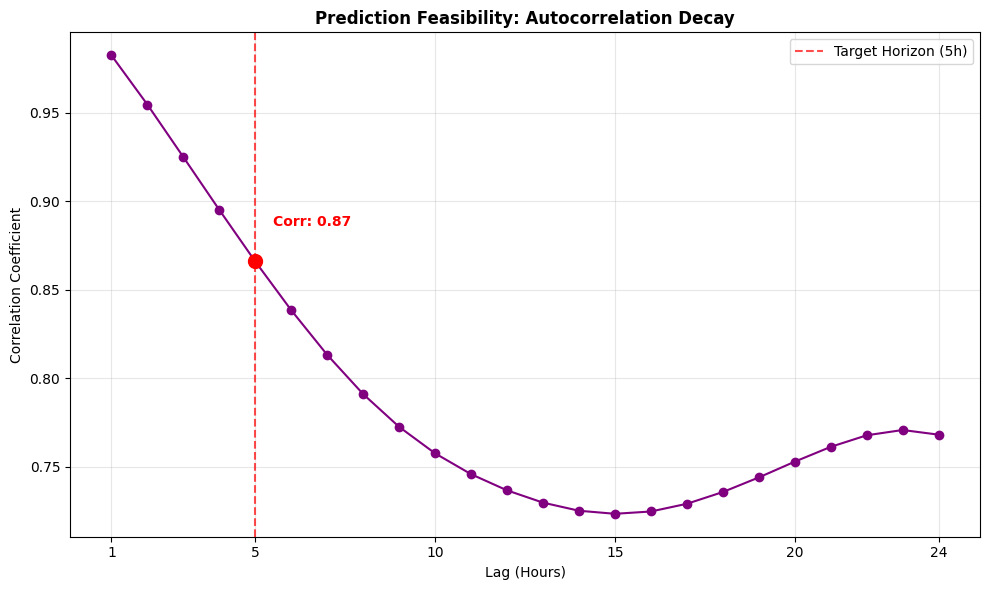

In [23]:
# Calculate autocorrelation for lags 1-24
lags = range(1, 25)
correlations = [data['availableBikeNumber'].autocorr(lag=lag) for lag in lags]
target_corr = correlations[4]  # index 4 is lag 5

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(lags, correlations, marker='o', linestyle='-', color='purple')
ax.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Target Horizon (5h)')
ax.scatter(5, target_corr, color='red', s=100, zorder=5)
ax.text(5.5, target_corr + 0.02, f'Corr: {target_corr:.2f}', color='red', fontweight='bold')

ax.set_title('Prediction Feasibility: Autocorrelation Decay', fontsize=12, fontweight='bold')
ax.set_xlabel('Lag (Hours)')
ax.set_ylabel('Correlation Coefficient')
ax.set_xticks([1, 5, 10, 15, 20, 24])
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


- The autocorrelation at our target horizon (lag-5) is **0.87**, indicating a strong positive relationship between current and future bike availability.

Key observations:
- **High Persistence**: Correlation remains above 0.75 even at 24-hour lags, confirming the stable nature of bike availability.
- **Feasible Task**: A correlation of ~0.87 at 5 hours means current availability explains roughly 75% of the variance in future availability (r² ≈ 0.75).
- **Baseline Strength**: This also explains why naive persistence is a strong baseline—the best single predictor of future availability *is* current availability.
<br><br>

- The LSTM must learn patterns beyond simple persistence (e.g., time-of-day effects, station-specific behaviors (weather would have been nice here but its not available)) to improve upon this baseline.

### 4.3 Spatial Volatility (Station Difficulty Mapping)

- Not all stations are equally predictable. Stations with high usage turnover (e.g., near transit hubs) will show more variance than quiet residential stations.

- We quantify this by computing the **standard deviation of bike availability** for each station—a measure of volatility. High-volatility stations are "harder" to predict because their bike counts fluctuate more. Low-volatility stations are "easier" because they remain stable.

- Mapping this spatially helps us understand:
    1. Which areas of Kiel have the most dynamic bike usage
    2. How important the understanding of relative position of the stations towards eachother is

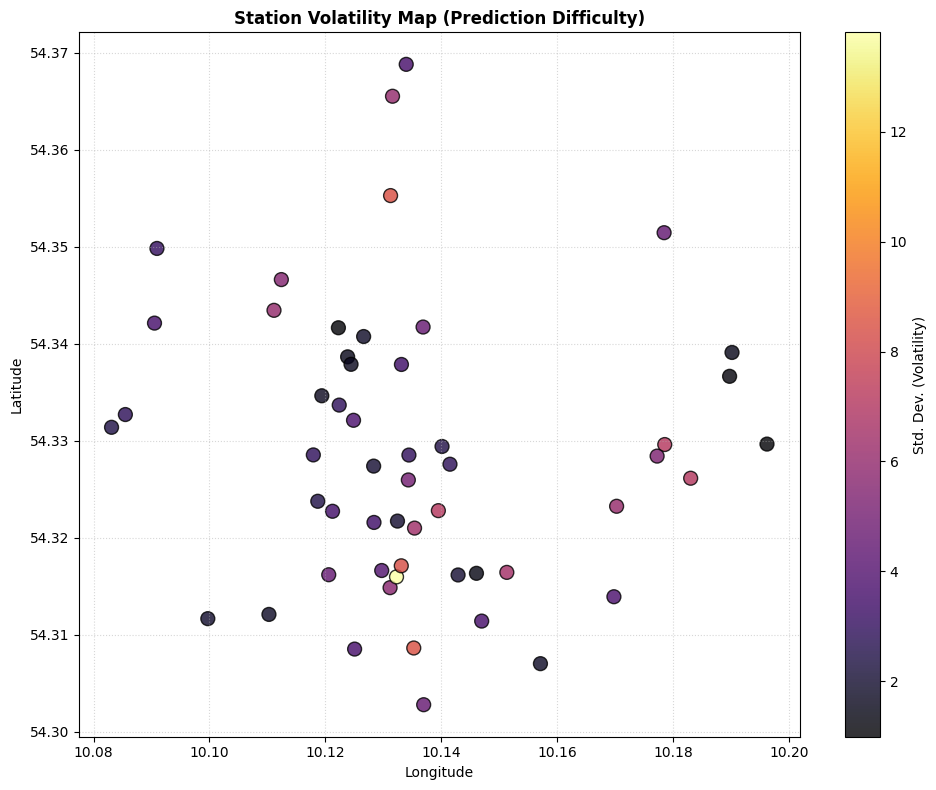

Volatility range: 0.99 - 13.81 bikes (mean: 4.01)


In [24]:
# Calculate volatility (std dev) per station
station_stats = data.groupby('entityId').agg({
    'availableBikeNumber': 'std', 
    'latitude': 'first', 
    'longitude': 'first'
}).rename(columns={'availableBikeNumber': 'volatility'})

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    station_stats['longitude'], 
    station_stats['latitude'], 
    c=station_stats['volatility'], 
    cmap='inferno', 
    s=100, 
    edgecolor='black', 
    alpha=0.8
)
plt.colorbar(sc, ax=ax, label='Std. Dev. (Volatility)')

ax.set_title('Station Volatility Map (Prediction Difficulty)', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Print interpretation
min_vol = station_stats['volatility'].min()
max_vol = station_stats['volatility'].max()
mean_vol = station_stats['volatility'].mean()

print(f"Volatility range: {min_vol:.2f} - {max_vol:.2f} bikes (mean: {mean_vol:.2f})")

- **High volatility (bright colors)**: There are two station clusters with higher fluctuation. Around central station (around 54.315/10.13 lat/long) and on the middle part of the eastern shore (around 54.325/10.18 lat/long). Stations next to the highest volatility station also show very high volatility.
- **Low volatility (dark colors)**: Peripheral stations remain more stable throughout the day.
<br> 

- For model evaluation, we should expect higher errors at high-volatility stations—this is inherent difficulty, not model failure. Root Mean Squared Error will be a good measure to identify how well a model performs despite this difficulty

## 5. Task 5 - Evaluation and Baseline

- Before training deep learning models, we establish the evaluation framework and a performance baseline.

- The baseline represents the simplest reasonable approach to the prediction task. If our LSTM cannot outperform it, we must question whether the added complexity is worthwhile for this use case.

- Alongside we this chapter will create a Temporal Train-Test Split. We must split by **Time**, not by Station or DataFrame length, to ensure the model learns the history of *all* stations before being tested on *all* stations future.

### 5.1 Evaluation Metrics

We select two complementary metrics to evaluate model performance:

**Mean Absolute Error (MAE)**:
* Measures the average magnitude of prediction errors in the original unit (bikes)

**Root Mean Squared Error (RMSE)**
* Also measures error magnitude but penalizes large errors more heavily due to the squaring operation. This is relevant for our use case because significantly mispredicting bike availability (e.g., predicting 10 bikes when there are 0) is operationally worse than many small errors.

**Why These Metrics for Bike Prediction?**

- Both metrics are in interpretable units (number of bikes), making results actionable for operations teams.
- MAE provides a robust central estimate of typical error magnitude.
- RMSE highlights whether the model makes occasional large mistakes that could cause empty or overflowing stations.
- Together, comparing MAE and RMSE reveals error distribution characteristics: if RMSE >> MAE, the model has high-variance errors.

In [25]:
### 5.1 Evaluation Metrics Function

def evaluate_model(y_true, y_pred):
    """
    Calculates MAE and RMSE for model evaluation.
    
    Args:
        y_true (array-like): The actual target values (ground truth).
        y_pred (array-like): The model's predictions.
        
    Returns:
        dict: A dictionary containing 'MAE' and 'RMSE' scores.
    """
    
    # Calculate Mean Absolute Error: Average of absolute differences |y_true - y_pred|
    mae = mean_absolute_error(y_true, y_pred)
    
    # Calculate Root Mean Squared Error: Sqrt of average squared differences (y_true - y_pred)^2
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    return {'MAE': mae, 'RMSE': rmse}

### 5.2 Baseline: Naive Persistence

**Method:** We predict that the bike availability 5 hours from now will be exactly the same as the current availability.
* **Formula:** $\hat{y}_{t+5} = x_t$

**Why This Baseline?**

- Bike availability is highly autocorrelated—if a station has 5 bikes now, it's likely to have a similar count in 5 hours. Our EDA (4.2) confirmed this. This makes naive persistence a strong baseline that captures the dominant pattern in the data.

In [26]:
### 5.2 Create Naive Persistence Baseline

# We create a new column 'baseline_pred' which effectively just copies the current 'availableBikeNumber'.
# Since our target is 't+5', using the current value 't' as a prediction is the "Persistence" strategy.
data['baseline_pred'] = data['availableBikeNumber']

# Quick verify: Check the first few rows to see that the prediction equals the current value
print("Baseline column created. Preview:")
print(data[['availableBikeNumber', 'baseline_pred']].head(10))

Baseline column created. Preview:
   availableBikeNumber  baseline_pred
0             1.983333       1.983333
1             1.000000       1.000000
2             1.450000       1.450000
3             2.000000       2.000000
4             2.000000       2.000000
5             2.000000       2.000000
6             2.133333       2.133333
7             4.000000       4.000000
8             4.633333       4.633333
9             2.933333       2.933333


### 5.3 Train-Test-Validation Split

We split the data **chronologically** to ensure that all stations are equally contained in all sets.

**Split Strategy:**
- **Training Set & Validation Set (80%)**: The first ~14 weeks of data. Within this we will split into Training and Validation set (80/20).
- **Test Set (20%)**: The final ~3 weeks of data. Used exclusively for final evaluation—the model never sees this data during training.
```
Train (80%) ─────────────────────────────────► Test (20%)
     │                                              │
     ├── Train-Train (80% of train) ── training     │
     │                                              │
     └── Train-Val (20% of train) ── early stopping │
                                                    │
                                         final evaluation only
```

In [27]:
### 5.3 Temporal Train-Validation-Test Split 

# We sort primarily by 'index' (Time).
# Secondary sort by 'entityId' ensures deterministic order for rows with same timestamp. This is redundant but I did not work on the tasks in a linear manner and I leave it in to avoid any unforseen mistakes.
data_sorted = data.sort_values(by=['index', 'entityId']).reset_index(drop=True)

# HELPER FUNCTION: PREVENT SPLITTING MID-TIMESTAMP -> This was added later because sets had unequal amounts of data per station
def get_clean_split_index(df, split_fraction):
    """
    Calculates a split index that does not cut in the middle of a specific timestamp.
    It moves the index forward to include ALL rows of the distinct timestamp 
    where the fraction lands.
    """
    target_idx = int(len(df) * split_fraction)
    
    # Identify the timestamp where the hard cut would happen
    split_time = df.iloc[target_idx]['index']
    
    # Find the first index of the *next* timestamp
    # This ensures we don't put half of '10:00 AM' in Train and half in Val
    next_idx_series = df[df['index'] > split_time].index
    
    if len(next_idx_series) > 0:
        return next_idx_series[0] # Return the start of the next hour
    else:
        return target_idx # Fallback if we are at the very end of the data

# FIRST SPLIT: 80% train+val, 20% test
# Use the helper function instead of simple int conversion
test_split_idx = get_clean_split_index(data_sorted, 0.8)

trainval_data = data_sorted.iloc[:test_split_idx].copy()
test_data = data_sorted.iloc[test_split_idx:].copy()

# SECOND SPLIT: 80% train, 20% val (of the trainval portion)
# Use the helper function again on the trainval portion
val_split_idx = get_clean_split_index(trainval_data, 0.8)

train_data = trainval_data.iloc[:val_split_idx].copy()
val_data = trainval_data.iloc[val_split_idx:].copy()

# Verification
print(f"Total Rows: {len(data_sorted):,}")
print(f"Train Size: {len(train_data):,} rows ({len(train_data)/len(data_sorted)*100:.1f}%)")
print(f"Val Size:   {len(val_data):,} rows ({len(val_data)/len(data_sorted)*100:.1f}%)")
print(f"Test Size:  {len(test_data):,} rows ({len(test_data)/len(data_sorted)*100:.1f}%)")

print(f"\nTrain Period: {train_data['index'].min()} --> {train_data['index'].max()}")
print(f"Val Period:   {val_data['index'].min()} --> {val_data['index'].max()}")
print(f"Test Period:  {test_data['index'].min()} --> {test_data['index'].max()}")

# Check temporal leakage
# This should now pass because we snapped the split to the hour boundary
assert train_data['index'].max() < val_data['index'].min(), "ERROR: Train/Val temporal overlap!"
assert val_data['index'].max() < test_data['index'].min(), "ERROR: Val/Test temporal overlap!"
print("\n No temporal leakage between splits.")

# Check staion coverage
print(f"\nStation Coverage Check:")
train_stations = set(train_data['entityId'].unique())
val_stations = set(val_data['entityId'].unique())
test_stations = set(test_data['entityId'].unique())

print(f"Unique Stations in Train: {len(train_stations)}")
print(f"Unique Stations in Val:   {len(val_stations)}")
print(f"Unique Stations in Test:  {len(test_stations)}")

missing_in_val = train_stations - val_stations
missing_in_test = train_stations - test_stations

if missing_in_val:
    print(f" WARNING: {len(missing_in_val)} stations from Train are missing in Val")
else:
    print(" All Train stations are present in Val.")

if missing_in_test:
    print(f" WARNING: {len(missing_in_test)} stations from Train are missing in Test")
else:
    print(" All Train stations are present in Test.")

Total Rows: 215,730
Train Size: 138,132 rows (64.0%)
Val Size:   34,506 rows (16.0%)
Test Size:  43,092 rows (20.0%)

Train Period: 2025-06-17 08:00:00 --> 2025-10-01 21:00:00
Val Period:   2025-10-01 22:00:00 --> 2025-10-28 12:00:00
Test Period:  2025-10-28 13:00:00 --> 2025-11-30 18:00:00

 No temporal leakage between splits.

Station Coverage Check:
Unique Stations in Train: 54
Unique Stations in Val:   54
Unique Stations in Test:  54
 All Train stations are present in Val.
 All Train stations are present in Test.


### 5.4 Baseline Results and saving Baseline

In [28]:
### 5.4 Evaluate Baseline on Test Data
# Calculate baseline metrics using the function defined in 5.1
# We compare the 'target_5h' (truth) against 'baseline_pred' (prediction) ONLY for TEST data
baseline_results = evaluate_model(test_data['target_5h'], test_data['baseline_pred'])

print("BASELINE PERFORMANCE (Naive Persistence):")
print(f"MAE:  {baseline_results['MAE']:.4f} bikes")
print(f"RMSE: {baseline_results['RMSE']:.4f} bikes")

# Store these metrics in a dictionary to access them easily in later plots
baseline_metrics = {
    'model': 'Naive Persistence',
    'MAE': baseline_results['MAE'],
    'RMSE': baseline_results['RMSE']
}

BASELINE PERFORMANCE (Naive Persistence):
MAE:  1.4578 bikes
RMSE: 2.8335 bikes


* GOAL: The Deep Learning model must beat MAE 1.4578 bikes

## 6. Task 6 - Deep Learning Experiments

This section presents the core deep learning experiments for the bike availability prediction task. We build, train, and evaluate an LSTM-based model, comparing different weight initialization strategies to assess their impact on training stability and final performance.

**Experiment Overview:**
1. **Architecture Design**: Define an LSTM model suitable for multi-station time series prediction.
2. **Loss Function**: Select an appropriate objective for regression.
3. **Data Preparation**: Scale features and create PyTorch datasets with sliding windows.
4. **Training Utilities:**: Set up Classes and functions needed for the training loop.
5. **Training**: Train multiple models per initialization strategy with early stopping.
6. **Evaluation**: Compare strategies and select the best-performing model.

### 6.1 Model Architecture

**Selected Architecture: LSTM with Fully Connected Output Layer**

**Why LSTM for this task:**
- Designed specifically for sequential data with temporal dependencies
- Captures patterns across different time scales (hourly, daily cycles)
- Handles variable-length dependencies via gating mechanisms (forget, input, output gates)
- Well-established for time series forecasting tasks

Given the high autocorrelation observed in earlier analyses, an LSTM is a natural choice for modeling both short-term fluctuations and longer-term temporal trends.

#### GRU and Embedding layer options
- Although Gated Recurrent Units (GRUs) offer a more parameter-efficient alternative, they were no explicit part of the lectures so an LSTM was chosen (see taks sheet 5.3 a)).
- Using an embedding layer for the LSTM to identify distinct stations and safe behavioural characteristics of each station in would have been a great opportunity, but they are also not discussed in the lectures.

#### Dropout
Dropout is applied in two locations to mitigate overfitting:

- **Inter-layer dropout (p = 0.2)** within the stacked LSTM, active only between layers
- **Post-LSTM dropout (p = 0.2)** before the fully connected output layer

This combination provides regularization both within the recurrent stack and at the final prediction stage, improving generalization without significantly impairing temporal learning.


**Architecture Overview:**
```
Input: Features (batch_size, sequence_length=24, num_features=7)
    │
    ▼
┌─────────────────────────────────────────────────┐
│  LSTM Layer                                     │
│  - input_size: 7 (7 features)                   │
│  - hidden_size: 64                              │
│  - num_layers: 2                                │
│  - batch_first: True                            │
│  - dropout: 0.2 (between LSTM layers)           │
└─────────────────────────────────────────────────┘
    │
    ▼ (take only last hidden state)
┌─────────────────────────────────────────────────┐
│  Dropout Layer (p=0.2)                          │
│  - Regularization before final prediction       │
└─────────────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────────────┐
│  Fully Connected Layer (64 → 1)                 │
│  - Maps LSTM output to single prediction        │
└─────────────────────────────────────────────────┘
    │
    ▼
Output (batch_size, 1) → Predicted bike count at t+5
```

#### Final Input Features (7 total)

| Feature | Description | Purpose |
|---------|-------------|---------|
| `availableBikeNumber` | Current bike count (scaled) | Primary signal for prediction |
| `day_sin` | Sine of time-of-day | Cyclical daily pattern |
| `day_cos` | Cosine of time-of-day | Cyclical daily pattern |
| `year_sin` | Sine of day-of-year | Cyclical seasonal pattern |
| `year_cos` | Cosine of day-of-year | Cyclical seasonal pattern |
| `latitude` | Station latitude | Spatial information |
| `longitude` | Station longitude | Spatial information |

#### Architectural Hyperparameters

| Component | Choice | Rationale |
|---------|--------|-----------|
| `hidden_size = 64` | Moderate capacity | Balances expressiveness and overfitting risk |
| `num_layers = 2` | Stacked LSTM | Enables hierarchical temporal feature learning |
| `dropout = 0.2` | Light regularization | Improves generalization on large dataset |
| `sequence_length = 24` | 24 hours | Captures a full daily usage cycle |

In [29]:
class BikePredictionLSTM(nn.Module):
    """
    LSTM model for predicting bike availability 5 hours ahead.
    
    Architecture:
        Features -> LSTM (2 layers) -> Dropout -> Fully Connected
    
    Args:
        input_size: Number of time-series features per timestep (7)
        hidden_size: Number of LSTM hidden units (64)
        num_layers: Number of stacked LSTM layers (2)
        dropout: Dropout probability (0.2)
    """
    
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(BikePredictionLSTM, self).__init__()
        
        # Store parameters
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Dropout Layer (Regularization)
        # Applied to the final hidden state before the dense layer
        self.dropout = nn.Dropout(p=dropout)
        
        # Fully connected output layer
        # Maps the LSTM output (64 dims) to the single target value (1 dim)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Input features (batch_size, sequence_length=24, num_features=7)
        
        Returns:
            Predictions (batch_size, 1)
        """
        # Pass through LSTM
        # lstm_out has shape (batch_size, 24, hidden_size=64) -> output for ALL 24 timesteps
        lstm_out, _ = self.lstm(x)
        
        # Take only the last hidden state
        # Slice: [:, -1, :] which means "all batches, but only the last timestep"
        last_hidden = lstm_out[:, -1, :]
        
        # Apply dropout and project to single target value
        out = self.dropout(last_hidden)
        out = self.fc(out)
        
        return out


### Model and training configurations

CONFIG = {
    # Data parameters
    'sequence_length': 24,          # 24 hours of history
    'prediction_horizon': 5,        # Predict 5 hours ahead
    'batch_size': 128,              # Batch size decision explained later on
    
    # Model parameters
    'input_size': 7,                # Number of time-series features
    'hidden_size': 64,              # LSTM hidden units
    'num_layers': 2,                # LSTM layers
    'dropout': 0.2,
    
    # Training parameters
    'learning_rate': 0.001,
    'max_epochs': 100,
    'early_stopping_patience': 10,
    
    # Experiment parameters
    'runs_per_strategy': 5,
    'model_dir': 'models/',
    
    # Reproducibility
    'base_seed': RANDOM_SEED
}

batch_first = True:
- In PyTorch, this configures the expected input shape as (Batch_Size, Sequence_Length, Features). The LSTM module automatically iterates along the Sequence_Length dimension (the rows 0 to 23) in increasing order. You do not need to manually loop through them; the self.lstm(x) call does this internally.

### 6.2 Loss Function
Because the tasks sheet asks early (6.3 d) for the choosing of the loss function this chapter will shortly describe and explain our choice.

**Selected: Mean Squared Error (MSE)**

**Formula:** `MSE = (1/n) × Σ(y_true - y_pred)²`

**Why MSE:**
- Standard loss for regression tasks
- Penalizes large errors quadratically → model prioritizes avoiding big mistakes
- Smooth and differentiable everywhere → stable gradient computation
- Directly related to RMSE evaluation metric: `RMSE = √MSE`

Apart from these reasons MSE loss was a well performing loss function in the first experiment iteration (Application Project). For a more intuitively understandable code structure the loss will be intitialized later inside the training function (6.5) before the training loop.

In [30]:
### Set device to cuda if possible, cpu otherwise
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 6.3 Data Preparation & Engineering

Before training, we must transform the preprocessed data into a format suitable for PyTorch and LSTM consumption. This involves two steps: **Feature Scaling** and creating the **Sliding Window Dataset** through a Dataset class (for creating sliding windows as tensors) and Dataloaders.


**1. Feature Scaling**
* **Method:** `MinMaxScaler` (Range 0 to 1).
* **Rationale:** LSTMs are sensitive to the scale of input data, particularly because the architecture uses `tanh` and `sigmoid` activation functions. Large values (like Latitude ~54.0 or Bike Counts ~60) can be problematic for gradients. Evethough an LSTM is not as vulnerable as an RNN, Scaling everything to [0, 1] ensures stable training.
* **Implementation:** We fit the scaler **only** on the training set to prevent data leakage, then transform both training and test sets.

**2. Sequence Generation (Sliding Window)**
* **Method:** We use a custom PyTorch `Dataset` class to create sliding window instances as tensors.
* **Input ($X$):** A window of **24 hours** (history) containing all 7 features.
* **Target ($y$):** The bike count **5 hours after** the end of the input window.
* **Dataloader:** We will then initiate these window tensors inside a Dataloader (shuffle = True for training) with batchsize 128 (compromise between training speed (not too small batches) and gradient stability (not too large batches))

**Minor Temporal Overlap in Targets**

There is a small overlap to acknowledge: The `target_5h` column was created by shifting `availableBikeNumber` by -5 hours. This means the last 5 training samples per station have targets that reference bike counts occurring in the chronologically next set. 
This affects 5 out of ~3200 hours per station (~0.15%), which has negligible practical impact on model training.

In [31]:
### 1. Feature Selection & Scaling
# We scale inputs to [0, 1] because LSTMs (using tanh/sigmoid) are sensitive
# to magnitude. Large inputs (like Lat/Lon ~54.0) can slow down convergence.
feature_cols = ['availableBikeNumber', 'day_sin', 'day_cos',
                'year_sin', 'year_cos', 'latitude', 'longitude']
target_col = 'target_5h'

# CRITICAL: Fit scalers on TRAIN data only to avoid data leakage
scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# Fit on train only
scaler.fit(train_data[feature_cols])
target_scaler.fit(train_data[[target_col]])

# Apply transformation to all three sets
train_scaled = train_data.copy()
val_scaled = val_data.copy()
test_scaled = test_data.copy()

train_scaled[feature_cols] = scaler.transform(train_data[feature_cols])
train_scaled[target_col] = target_scaler.transform(train_data[[target_col]])

val_scaled[feature_cols] = scaler.transform(val_data[feature_cols])
val_scaled[target_col] = target_scaler.transform(val_data[[target_col]])

test_scaled[feature_cols] = scaler.transform(test_data[feature_cols])
test_scaled[target_col] = target_scaler.transform(test_data[[target_col]])

In [32]:
### 2.1 Custom Dataset Class
class BikeDataset(Dataset):
    """
    PyTorch Dataset for bike availability prediction.
    Creates sliding windows of 'sequence_length' hours for LSTM input anmd returns as tensors.
    """
    
    def __init__(self, df, feature_cols, sequence_length=24):
        self.sequence_length = sequence_length
        self.feature_cols = feature_cols
        self.samples = []
        
        # Group data by station
        for station_id, group in df.groupby('entityId'):
            group = group.sort_values('index').reset_index(drop=True)
            
            # Extract features and targets as numpy arrays
            features = group[feature_cols].values
            targets = group['target_5h'].values
            
            # Identify valid sequences (sliding window)
            n_valid_sequences = len(group) - sequence_length
            
            for i in range(n_valid_sequences):
                # Input: Rows i to i+24 (24 hours)
                # Target: The target associated with the LAST step of the window
                self.samples.append({
                    'features': features[i:i + sequence_length],
                    'target': targets[i + sequence_length - 1]
                })
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Convert to PyTorch tensors
        features = torch.tensor(sample['features'], dtype=torch.float32)
        target = torch.tensor(sample['target'], dtype=torch.float32).unsqueeze(0)
        
        return features, target
    
## 2.2 Create DataLoaders
BATCH_SIZE = CONFIG['batch_size'] # (128)

# Create datasets
train_dataset = BikeDataset(train_scaled, feature_cols, CONFIG['sequence_length'])
val_dataset = BikeDataset(val_scaled, feature_cols, CONFIG['sequence_length'])
test_dataset = BikeDataset(test_scaled, feature_cols, CONFIG['sequence_length'])

# Create loaders
# shuffle=True for training to break correlations, False for val/test
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}")

Train samples: 136836
Val samples: 33210
Test samples: 41796
Train batches: 1069


#### 6.3.1 Data Verification (Sanity Check)

**Objective:**
Before initializing the model, we verify that the `DataLoader` yields batches with the correct shapes and sample/target matches.

**Checks Performed:**
1.  **Batch Shapes:** Confirm inputs are `[128, 24, 7]` and targets are `[128, 1]`.
2.  **Target Inspection:** Inverse-transform a series of samples with target to ensure it the targets reappear in the subsequent samples t+0.

In [33]:
# =============================================================================
# 6.3.1 Data Verification - Full Window Inspection
# =============================================================================

# Get one batch from test loader (ordered data)
features, targets = next(iter(test_loader))

print("=== DataLoader Verification ===")
print(f"Features shape: {features.shape}  (batch, sequence_length, num_features)")
print(f"Targets shape:  {targets.shape}")

# Show first 2 complete windows (unscaled)
for i in range(7):
    print(f"\n{'='*60}")
    print(f"SAMPLE {i}")
    print(f"{'='*60}")
    
    # Inverse transform bike counts (feature 0) for all 24 timesteps
    bikes_scaled = features[i, :, 0].numpy().reshape(-1, 1)
    bikes_real = target_scaler.inverse_transform(bikes_scaled).flatten()
    
    # Target
    target_real = target_scaler.inverse_transform([[targets[i].item()]])[0, 0]
    
    # Create DataFrame and print it
    df = pd.DataFrame({
        'hour': range(24),
        'bikes': bikes_real.round(1),
        'day_sin': features[i, :, 1].numpy().round(3),
        'day_cos': features[i, :, 2].numpy().round(3),
        'year_sin': features[i, :, 3].numpy().round(3),
        'year_cos': features[i, :, 4].numpy().round(3),
        'lat': features[i, :, 5].numpy().round(4),
        'lon': features[i, :, 6].numpy().round(4),
    })
    
    print(df.to_string(index=False))
    print(f"\n→ Target (t+5h): {target_real:.1f} bikes")


=== DataLoader Verification ===
Features shape: torch.Size([128, 24, 7])  (batch, sequence_length, num_features)
Targets shape:  torch.Size([128, 1])

SAMPLE 0
 hour     bikes  day_sin  day_cos  year_sin  year_cos    lat   lon
    0 15.000000    0.371    0.017     0.087     1.437 0.4063 0.844
    1 15.000000    0.250    0.067     0.087     1.438 0.4063 0.844
    2 15.000000    0.146    0.146     0.087     1.438 0.4063 0.844
    3 15.000000    0.067    0.250     0.087     1.439 0.4063 0.844
    4 15.000000    0.017    0.371     0.088     1.440 0.4063 0.844
    5 15.000000    0.000    0.500     0.088     1.440 0.4063 0.844
    6 15.000000    0.017    0.629     0.088     1.441 0.4063 0.844
    7 15.900000    0.067    0.750     0.088     1.442 0.4063 0.844
    8 16.000000    0.146    0.854     0.089     1.442 0.4063 0.844
    9 16.000000    0.250    0.933     0.089     1.443 0.4063 0.844
   10 16.000000    0.371    0.983     0.089     1.443 0.4063 0.844
   11 16.000000    0.500    1.000   

* We can see that batch shape is correct and that the target of the first sample (14 bikes) appears in the last (t+0) row of the 5th sample. Same goes for the second and 6th sample (12.2 bikes).

### 6.5 Training Utilities

To ensure reproducible, and controlled deep learning experiments, we implement modular training utilities that are reused across all model runs in Task 6. This design guarantees that differences in model performance arise solely from the experimental variable under investigation (weight initialization), rather than from variations in training logic.

#### Early Stopping

An `EarlyStopping` utility is implemented to monitor validation loss during training and prevent overfitting. Training is terminated if the validation loss does not improve by at least `min_delta` for a fixed number of consecutive epochs (`patience`).

Key characteristics:
- **Monitors validation loss only** (never test data)
- **Restores the best model weights**, not the final epoch weights
- **Reduces overfitting risk** and unnecessary computation
- **Improves comparability** across experimental runs

This approach ensures that each model is evaluated at its optimal generalization point rather than at an arbitrary final epoch.

#### Single-Run Training Function (`train_one_run`)

The `train_one_run` function encapsulates the complete training life-cycle for a single model instance. It provides a standardized and reusable training procedure applied consistently across all experiments.

The training process consists of:
1. Iterative training over a maximum number of epochs
2. Forward and backward passes on the training set
3. Evaluation on a dedicated validation set after each epoch
4. Early stopping based on validation loss
5. Automatic restoration of the best-performing model weights

The function returns:
- Epoch-wise training and validation loss history
- The best validation loss achieved
- Total training time for the run

By centralizing the training logic in a single function, all experimental runs (different initialization) are executed under identical conditions, ensuring a fair and controlled comparison.


In [34]:
### Training Helper Classes & Functions

### Early Stopping
class EarlyStopping:
    """
    Stops training if validation loss doesn't improve after a given 'patience'.
    """
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_wts = None
    
    def __call__(self, val_loss, model):
        # First epoch: set baseline
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
        # Improvement found
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0
        # No improvement
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

### Training Function
def train_one_run(model, train_loader, val_loader, criterion, optimizer, 
                  CONFIG, device, run_name=""):
    """
    Encapsulates the entire training life-cycle for a single model instance.
    
    Args:
        model: Initialized PyTorch model
        train_loader: DataLoader for training data
        val_loader: DataLoader for VAL/EARLY STOPPING data (not test data!)
        criterion: Loss function (MSELoss -> Choice explained in 6.2)
        optimizer: Optimizer (e.g., Adam)
        CONFIG: Dictionary containing 'max_epochs', 'patience' for early stopping
        device: 'cuda' or 'cpu'
        run_name: String for printing progress (e.g., "Xavier-Run-1")
    
    Returns:
        history: Dictionary containing 'train_loss' and 'val_loss' per epoch
        best_val_loss: The best validation loss achieved
        training_time: Total training time in seconds
    """
    # Extract config parameters with sensible defaults
    max_epochs = CONFIG.get('max_epochs', 100)
    patience = CONFIG.get('early_stopping_patience', 10)
    
    # Initialize early stopping to prevent overfitting
    # Monitors val_loss and saves best model weights automatically
    early_stopper = EarlyStopping(patience=patience, min_delta=0)
    
    # Track losses for later visualization of training curves
    history = {'train_loss': [], 'val_loss': []}
    start_time = time.time()
    
    for epoch in range(max_epochs):
        # TRAINING PHASE
        # model.train() enables dropout and batch normalization in training mode
        model.train()
        running_train_loss = 0.0
        
        for inputs, targets in train_loader:
            # Move data to GPU/CPU
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            # Zero gradients from previous batch (PyTorch accumulates gradients by default)
            optimizer.zero_grad()
            
            # Forward pass: compute predictions
            predictions = model(inputs)
            
            # Compute loss (MSE between predictions and targets)
            loss = criterion(predictions, targets)
            
            # Backward pass: compute gradients via backpropagation
            loss.backward()
            
            # Update weights using computed gradients
            optimizer.step()
            
            # Accumulate loss weighted by batch size for accurate epoch average
            running_train_loss += loss.item() * inputs.size(0)
        
        # Calculate average training loss across all samples
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)
        
        # VALIDATION PHASE
        # model.eval() disables dropout and sets batch norm to inference mode
        model.eval()
        running_val_loss = 0.0
        
        # torch.no_grad() disables gradient computation for efficiency
        # (no backprop needed during validation)
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                
                predictions = model(inputs)
                loss = criterion(predictions, targets)
                running_val_loss += loss.item() * inputs.size(0)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        history['val_loss'].append(epoch_val_loss)
        
        # EARLY STOPPING CHECK
        # Check if val_loss improved; if so, save model weights internally
        early_stopper(epoch_val_loss, model)
        
        # If no improvement for 'patience' epochs, stop and restore best weights
        if early_stopper.early_stop:
            model.load_state_dict(early_stopper.best_model_wts)
            break
    
    training_time = time.time() - start_time
    
    # If training completed all epochs without early stopping,
    # still load the best weights (not the final epoch's weights)
    if not early_stopper.early_stop and early_stopper.best_model_wts is not None:
        model.load_state_dict(early_stopper.best_model_wts)
    
    return history, early_stopper.best_loss, training_time

### 6.6 Experiment Execution

This section executes the core deep learning experiment of Task 6: a controlled comparison of weight initialization strategies for the LSTM-based bike availability prediction model. All experiments use the same architecture, data splits, training procedure, and hyperparameters, ensuring that observed differences are attributable solely to the initialization method.

#### Weight Initialization Strategies

We evaluate three commonly used initialization strategies with distinct theoretical motivations:

1. **Xavier (Glorot) Uniform**  
   Designed for layers with sigmoid or tanh activations, Xavier initialization scales weights based on fan-in and fan-out to preserve variance across layers. This is the standard recommendation for LSTMs and serves as the primary baseline.

2. **Kaiming (He) Normal**  
   Designed for ReLU-based networks, Kaiming initialization is included as a contrast. Since LSTMs rely on tanh and sigmoid activations, this strategy is theoretically mismatched and may lead to suboptimal gradient flow.

3. **Orthogonal**  
   Initializes weight matrices as orthogonal matrices, which is particularly beneficial for recurrent networks. Orthogonal initialization helps preserve gradient magnitude during backpropagation through time and is often recommended for RNN/LSTM models.

For experimental comparability, each strategy is applied uniformly to all learnable weight matrices in the model. While individual more granular schemes (e.g. separate handling of input and recurrent weights) are possibly more optimal for each sttrategy, uniform application enables a clean comparison of the overall effect of each strategy.

#### Experimental Protocol

- **Repetitions:** Each initialization strategy is trained using **5 independent runs** with different random seeds (15 runs total).
- **Controlled Variables:** All hyperparameters, data splits, and training logic remain fixed across runs.
- **Early Stopping:** Validation loss is used exclusively for early stopping and model selection.
- **Evaluation:** Final performance is measured with on a held-out test set that is never used during training.

This setup allows assessment of both:
- **Average performance** (generalization quality)
- **Training stability** (variance across runs and convergence behavior)

#### Metrics Tracked

For each run, the following metrics are recorded:
- **Best Validation Loss:** Indicates convergence quality during training.
- **Test MAE and RMSE:** Measure final predictive performance on real (unscaled) bike counts.
- **Epochs Trained:** Reflects convergence speed via early stopping.
- **Training Time:** Captures computational efficiency.

#### Reproducibility, Checkpoint Handling, and Run Variability

To support both reproducibility and efficient experimentation, the training pipeline explicitly distinguishes between loading existing models and training new ones. Each experimental run is associated with a unique checkpoint file. If a checkpoint already exists and `FORCE_RETRAIN` is set to `False`, the model and its recorded metrics are loaded from disk and reused. When `FORCE_RETRAIN` is enabled, all models are retrained from scratch, regardless of existing checkpoints.

To ensure that repeated runs of the same initialization strategy yield independent outcomes, each run is executed with a distinct random seed. The seed is derived deterministically from a fixed base seed and the run index, and is applied prior to model initialization. This affects weight initialization, data shuffling, and optimizer behavior.

As a result:
- Multiple runs per strategy reflect genuine stochastic variability rather than duplicated training
- Performance variance provides insight into training stability
- Experiments remain fully reproducible when rerun with the same configuration

In [35]:
### Experiment Execution

# Set experiment-level variables
# Initialization strategies to compare
strategies = ['xavier', 'kaiming', 'orthogonal']

# List for collecting final per-run results (used for DataFrame analysis)
results_list = []

# Dictionary for storing full training histories (loss curves)
training_histories = {}


### Robust path handling for model checkpoints
# Explicitly control where trained models are saved to avoid ambiguity
# and filesystem-related errors across different execution environments.

# Print current working directory for debugging and reproducibility
print(f"Current Working Directory: {os.getcwd()}")

# Force model directory to be 'resources/models' relative to the notebook
# This avoids reliance on older or inconsistent CONFIG paths
MODEL_DIR = os.path.join(os.getcwd(), 'resources', 'models')

# Ensure the directory exists (prevents FileNotFoundError on save)
try:
    os.makedirs(MODEL_DIR, exist_ok=True)
    print(f"Directory verified/created at: {os.path.abspath(MODEL_DIR)}")
except Exception as e:
    print(f"Failed to create directory: {e}")

# Report experiment configuration to the console
print(f"Force Retraining: {'YES' if FORCE_RETRAIN else 'NO'}")
print("Starting Experiment: 3 strategies x 5 runs each...")
print("=" * 60)
print("Note: Early stopping uses VALIDATION set, final metrics use TEST set.")
print("=" * 60)


### Main experimental loop
# Outer loop: initialization strategy
# Inner loop: independent runs with different random seeds

for strategy in strategies:
    for run in range(1, CONFIG['runs_per_strategy'] + 1):
        
        # Unique identifier for this experimental run
        run_id = f"{strategy}_run{run}"
        filename = f"{run_id}.pt"
        filepath = os.path.join(MODEL_DIR, filename)
        
        # Seed handling
        current_seed = CONFIG['base_seed'] + run
        torch.manual_seed(current_seed)
        
        ### Optional checkpoint loading (skip retraining if allowed)
        if not FORCE_RETRAIN and os.path.exists(filepath):
            print(f"[{run_id}] Loading existing model...", end=" ")
            try:
                checkpoint = torch.load(filepath, map_location=device)
                results_list.append({
                    'strategy': strategy,
                    'run': run,
                    'seed': current_seed,
                    'best_val_loss': checkpoint.get('best_val_loss', None),
                    'test_mae': checkpoint.get('test_mae', None),
                    'test_rmse': checkpoint.get('test_rmse', None),
                    'epochs_trained': checkpoint.get('epochs_trained', None),
                    'training_time': checkpoint.get('training_time', None)
                })
                print("Done.")
                continue
            except Exception as e:
                # If loading fails, fall back to retraining
                print(f"Failed to load, retraining: {e}")
        
        # Train a fresh model instance
        print(f"[{run_id}] Training...", end=" ")
        
        # Create a new model instance to avoid any weight leakage
        model = BikePredictionLSTM(
            input_size=CONFIG['input_size'],
            hidden_size=CONFIG['hidden_size'],
            num_layers=CONFIG['num_layers'],
            dropout=CONFIG['dropout']
        ).to(device)
        
        ### Apply selected weight initialization strategy
        # Initialization is applied uniformly to all weight matrices.
        # Biases and 1D parameters are left untouched.
        for name, param in model.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                if strategy == 'xavier':
                    init.xavier_uniform_(param)
                elif strategy == 'kaiming':
                    init.kaiming_normal_(
                        param, mode='fan_in', nonlinearity='relu'
                    )
                elif strategy == 'orthogonal':
                    init.orthogonal_(param)
        
        # Define loss and optimizer (kept constant across all runs)
        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(
            model.parameters(), lr=CONFIG['learning_rate']
        )
        
        ### Training with early stopping (validation-based)
        # Validation data is used exclusively for early stopping.
        history, best_val_loss, training_time = train_one_run(
            model,
            train_loader,
            val_loader,
            criterion,
            optimizer,
            CONFIG,
            device,
            run_id
        )
        
        ### Save trained model checkpoint
        try:
            torch.save({
                'model_state_dict': model.state_dict(),
                'best_val_loss': best_val_loss,
                'epochs_trained': len(history['val_loss']),
                'training_time': training_time,
                'train_history': history['train_loss'],
                'val_history': history['val_loss'],
                'seed': current_seed,
                'strategy': strategy
            }, filepath)
        except Exception as e:
            print(f"\nCRITICAL ERROR SAVING MODEL: {e}")
            print(f"Attempted path: {filepath}")
        
        # Store full loss history for later analysis/visualization
        training_histories[run_id] = {
            'train_loss': history['train_loss'],
            'val_loss': history['val_loss'],
            'strategy': strategy,
            'run': run
        }
        
        ### Final evaluation on TEST set (true holdout)
        model.eval()
        test_preds = []
        test_targets = []
        
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                
                predictions = model(inputs)
                test_preds.extend(predictions.cpu().numpy())
                test_targets.extend(targets.cpu().numpy())
        
        # Inverse scaling to obtain real-world bike counts
        # Scalers expect 2D arrays, so reshape accordingly
        test_preds = np.array(test_preds).reshape(-1, 1)
        test_targets = np.array(test_targets).reshape(-1, 1)
        
        test_preds_real = target_scaler.inverse_transform(test_preds)
        test_targets_real = target_scaler.inverse_transform(test_targets)
        
        # Compute evaluation metrics on unscaled data
        metrics = evaluate_model(test_targets_real, test_preds_real)
        
        # Store final results for this run
        results_list.append({
            'strategy': strategy,
            'run': run,
            'seed': current_seed,
            'best_val_loss': best_val_loss,
            'test_mae': metrics['MAE'],
            'test_rmse': metrics['RMSE'],
            'epochs_trained': len(history['val_loss']),
            'training_time': training_time
        })
        
        print(f"MAE: {metrics['MAE']:.4f} | Time: {training_time:.1f}s")

# Experiment completed – aggregate results for analysis
print("=" * 60)
print("Experiment Complete.")

# Convert collected results into a DataFrame for downstream analysis
results_df = pd.DataFrame(results_list)
results_df


Current Working Directory: /Users/felix/Desktop/DL25/DL25_FelixHaack
Directory verified/created at: /Users/felix/Desktop/DL25/DL25_FelixHaack/resources/models
Force Retraining: NO
Starting Experiment: 3 strategies x 5 runs each...
Note: Early stopping uses VALIDATION set, final metrics use TEST set.
[xavier_run1] Loading existing model... Done.
[xavier_run2] Loading existing model... Done.
[xavier_run3] Loading existing model... Done.
[xavier_run4] Loading existing model... 

Done.
[xavier_run5] Loading existing model... Done.
[kaiming_run1] Loading existing model... Done.
[kaiming_run2] Loading existing model... Done.
[kaiming_run3] Loading existing model... Done.
[kaiming_run4] Loading existing model... Done.
[kaiming_run5] Loading existing model... Done.
[orthogonal_run1] Loading existing model... Done.
[orthogonal_run2] Loading existing model... Done.
[orthogonal_run3] Loading existing model... Done.
[orthogonal_run4] Loading existing model... Done.
[orthogonal_run5] Loading existing model... Done.
Experiment Complete.


,strategy,run,seed,best_val_loss,test_mae,test_rmse,epochs_trained,training_time
0,xavier,1,43,0.001144,None,None,26,239.614852
1,xavier,2,44,0.001162,None,None,25,236.357431
2,xavier,3,45,0.001142,None,None,23,210.997020
3,xavier,4,46,0.001136,None,None,37,334.060884
4,xavier,5,47,0.001131,None,None,37,334.332782
5,kaiming,1,43,0.001273,None,None,18,159.441984
6,kaiming,2,44,0.001266,None,None,20,175.422305
7,kaiming,3,45,0.001338,None,None,18,157.721151
8,kaiming,4,46,0.001217,None,None,23,201.590983
9,kaiming,5,47,0.001338,None,None,22,193.893001


* **Before we move to Results:** This training loop is hard to debug and if `FORCE_RETRAIN` is equal to `False` we are not saving `test_mae` and `test_rmse`. SO to take care of it we recompute the values outside of the training loop if the models were loaded from directory.

In [36]:
### Ensure results_df has real-scale metrics (needed if loaded from checkpoints)

if 'test_mae' not in results_df.columns or results_df['test_mae'].isna().all():
    print("Computing test metrics from saved models...")
    
    for idx, row in results_df.iterrows():
        run_id = f"{row['strategy']}_run{int(row['run'])}"
        filepath = os.path.join(MODEL_DIR, f"{run_id}.pt")
        
        if os.path.exists(filepath):
            checkpoint = torch.load(filepath, map_location='cpu')
            
            model = BikePredictionLSTM(
                input_size=CONFIG['input_size'],
                hidden_size=CONFIG['hidden_size'],
                num_layers=CONFIG['num_layers'],
                dropout=CONFIG['dropout']
            ).to(device)
            model.load_state_dict(checkpoint['model_state_dict'])
            model.eval()
            
            test_preds, test_targets = [], []
            with torch.no_grad():
                for inputs, targets in test_loader:
                    preds = model(inputs.to(device))
                    test_preds.extend(preds.cpu().numpy())
                    test_targets.extend(targets.cpu().numpy())
            
            # Inverse transform to real scale
            preds_real = target_scaler.inverse_transform(np.array(test_preds).reshape(-1, 1))
            targets_real = target_scaler.inverse_transform(np.array(test_targets).reshape(-1, 1))
            
            metrics = evaluate_model(targets_real, preds_real)
            results_df.loc[idx, 'test_mae'] = metrics['MAE']
            results_df.loc[idx, 'test_rmse'] = metrics['RMSE']
    
    print("Done.")
else:
    print("Test metrics already present in results_df.")

results_df.head()

Computing test metrics from saved models...
Done.


,strategy,run,seed,best_val_loss,test_mae,test_rmse,epochs_trained,training_time
0,xavier,1,43,0.001144,1.468704,2.38884,26,239.614852
1,xavier,2,44,0.001162,1.502396,2.385596,25,236.357431
2,xavier,3,45,0.001142,1.521454,2.317957,23,210.997020
3,xavier,4,46,0.001136,1.659968,2.625143,37,334.060884
4,xavier,5,47,0.001131,1.476873,2.3778,37,334.332782


### 6.7 Evaluation and Visualization

#### 6.7.1 Training Stability and Convergence Behavior (Training Curves)

In the context of this experiment, **convergence** refers to the point during training at which further optimization no longer yields meaningful improvements in validation loss. Operationally, convergence is detected via early stopping: when the validation loss stops improving for a predefined number of epochs, training is terminated and the best-performing model state is restored.

Thus, the number of epochs trained before early stopping serves as an indicator of:
- How efficiently the optimizer can minimize the loss
- How stable gradient propagation is during training
- How sensitive the training process is to random initialization

Across initialization strategies, distinct convergence patterns emerge:

'training_histories' is empty. Attempting to reload from saved models...
Searching in: /Users/felix/Desktop/DL25/DL25_FelixHaack/resources/models
  -> Loaded xavier_run1
  -> Loaded xavier_run2
  -> Loaded xavier_run3
  -> Loaded xavier_run4
  -> Loaded xavier_run5
  -> Loaded kaiming_run1
  -> Loaded kaiming_run2
  -> Loaded kaiming_run3
  -> Loaded kaiming_run4
  -> Loaded kaiming_run5
  -> Loaded orthogonal_run1
  -> Loaded orthogonal_run2
  -> Loaded orthogonal_run3
  -> Loaded orthogonal_run4
  -> Loaded orthogonal_run5


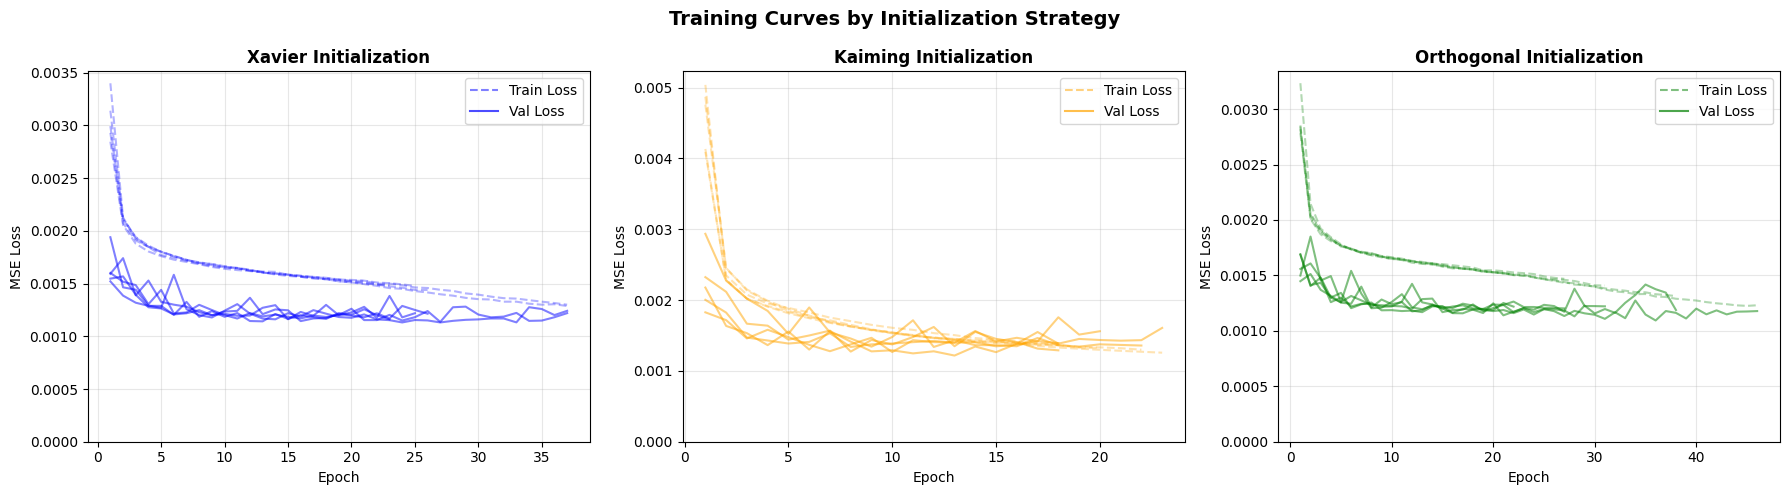


Convergence Summary:
Xavier       - Avg Epochs: 29.6, Final Val Loss: 0.001211 ± 0.000027
Kaiming      - Avg Epochs: 20.2, Final Val Loss: 0.001442 ± 0.000121
Orthogonal   - Avg Epochs: 32.8, Final Val Loss: 0.001202 ± 0.000017


In [37]:
### Training Curves Visualization (with Data Recovery)

#RECOVERY: Check if data is missing and reload from disk if needed (was needed for debugging)
if 'training_histories' not in locals() or not training_histories:
    print("'training_histories' is empty. Attempting to reload from saved models...")
    training_histories = {}
    
    # Ensure we look in the right place
    current_dir = os.getcwd()
    model_dir = os.path.join(current_dir, 'resources', 'models')
    
    if not os.path.exists(model_dir):
         # Fallback for alternative path structure
        model_dir = os.path.join(current_dir, 'models')

    print(f"Searching in: {model_dir}")
    
    strategies = ['xavier', 'kaiming', 'orthogonal']
    
    if os.path.exists(model_dir):
        for strategy in strategies:
            for run in range(1, 6): # Assuming 5 runs
                run_id = f"{strategy}_run{run}"
                filename = f"{run_id}.pt"
                filepath = os.path.join(model_dir, filename)
                
                if os.path.exists(filepath):
                    try:
                        checkpoint = torch.load(filepath, map_location='cpu')
                        # Recover history
                        training_histories[run_id] = {
                            'train_loss': checkpoint.get('train_history', []),
                            'val_loss': checkpoint.get('val_history', []),
                            'strategy': strategy,
                            'run': run
                        }
                        print(f"  -> Loaded {run_id}")
                    except Exception as e:
                        print(f"  -> Failed to load {filename}: {e}")
    else:
        print("Could not find model directory. Graphs will be empty.")
else:
    print(f"Found {len(training_histories)} runs in memory.")


### PLOTTING LOGIC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
strategy_colors = {'xavier': 'blue', 'kaiming': 'orange', 'orthogonal': 'green'}
strategies = ['xavier', 'kaiming', 'orthogonal']

for idx, strategy in enumerate(strategies):
    ax = axes[idx]
    
    # Filter: Get only runs for this strategy that actually have data
    valid_runs = [
        h for rid, h in training_histories.items() 
        if h['strategy'] == strategy and len(h.get('train_loss', [])) > 0
    ]
    
    if not valid_runs:
        ax.text(0.5, 0.5, "No Data Available", ha='center', va='center')
    
    for hist in valid_runs:
        epochs = range(1, len(hist['train_loss']) + 1)
        ax.plot(epochs, hist['train_loss'], 
                color=strategy_colors[strategy], alpha=0.3, linestyle='--')
        ax.plot(epochs, hist['val_loss'], 
                color=strategy_colors[strategy], alpha=0.5, linestyle='-')
    
    # Dummy lines for legend
    ax.plot([], [], color=strategy_colors[strategy], linestyle='--', alpha=0.5, label='Train Loss')
    ax.plot([], [], color=strategy_colors[strategy], linestyle='-', alpha=0.7, label='Val Loss')
    
    ax.set_title(f'{strategy.capitalize()} Initialization', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Training Curves by Initialization Strategy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### CONVERGENCE SUMMARY
print("\nConvergence Summary:")

for strategy in strategies:
    strategy_runs = [
        h for rid, h in training_histories.items() 
        if h['strategy'] == strategy and len(h.get('val_loss', [])) > 0
    ]
    
    if len(strategy_runs) == 0:
        print(f"{strategy.capitalize():12} - No successful runs data found.")
        continue

    avg_epochs = np.mean([len(h['val_loss']) for h in strategy_runs])
    final_val_losses = [h['val_loss'][-1] for h in strategy_runs]
    
    print(f"{strategy.capitalize():12} - Avg Epochs: {avg_epochs:.1f}, "
          f"Final Val Loss: {np.mean(final_val_losses):.6f} ± {np.std(final_val_losses):.6f}")

**Observed patterns:**

- **Xavier initialization** demonstrates **consistently low variance** in validation loss (± 0.000027) alongside strong average performance. It is however beaten in overall performance by the orthogonal initialization strategy.

- **Kaiming initialization** shows **substantially higher variance** in validation loss (± 0.000121) and earlier stopping on average. This is expected, as Kaiming initialization is designed for ReLU-based networks and does not align well with the `tanh` and `sigmoid` activations used in LSTMs. Consequently, training becomes more sensitive to random initialization, leading to less stable convergence and inferior average performance.

- **Orthogonal initialization** exhibits the **lowest variance** in validation loss (± 0.000017), indicating highly stable training across runs. This behavior aligns with theory, as orthogonal matrices preserve gradient magnitudes during repeated multiplication, which is particularly beneficial for recurrent connections. As a result, training dynamics are highly repeatable, albeit with slightly slower convergence, reflecting a trade-off between stability and speed.

These findings highlight that initialization affects not only final performance but also the optimization dynamics during training.

**Overfitting:**

The training curves show no evidence of overfitting, as training and validation losses decrease in tandem without a widening gap or late-epoch increase in validation loss, indicating that performance differences between initialization strategies primarily reflect optimization stability rather than generalization failure, with Xavier and Orthogonal initialization exhibiting more consistent convergence than Kaiming. If this is due to the dropout layers is hard to say, since we have no comparison experiments.

#### 6.7.2 Time Consumption Analysis

Early stopping behavior (and training time) provides additional insight into the optimization dynamics induced by different weight initialization strategies. Since early stopping is triggered based on validation loss, the number of epochs trained can be interpreted as a proxy for convergence speed and training stability.


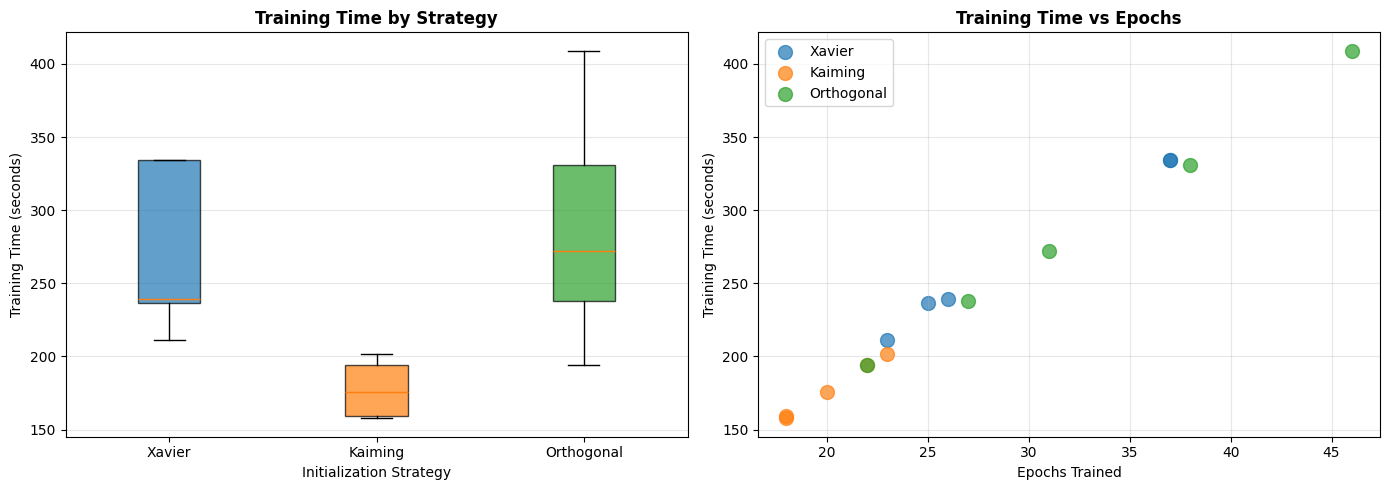


Time Consumption Summary:
              mean    std     min     max
strategy                                 
kaiming     177.61  19.82  157.72  201.59
orthogonal  288.93  83.71  194.25  409.04
xavier      271.07  58.68  211.00  334.33

Average time per epoch: 8.93 seconds


In [38]:

### Time Consumption Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training time by strategy
ax1 = axes[0]
time_data = [results_df[results_df['strategy'] == s]['training_time'].values for s in strategies]
bp1 = ax1.boxplot(time_data, labels=[s.capitalize() for s in strategies], patch_artist=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_title('Training Time by Strategy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Initialization Strategy')
ax1.set_ylabel('Training Time (seconds)')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Time vs Epochs
ax2 = axes[1]
for strategy in strategies:
    strategy_data = results_df[results_df['strategy'] == strategy]
    ax2.scatter(strategy_data['epochs_trained'], strategy_data['training_time'], 
                label=strategy.capitalize(), s=100, alpha=0.7)

ax2.set_title('Training Time vs Epochs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs Trained')
ax2.set_ylabel('Training Time (seconds)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTime Consumption Summary:")
time_summary = results_df.groupby('strategy')['training_time'].agg(['mean', 'std', 'min', 'max'])
print(time_summary.round(2))
print(f"\nAverage time per epoch: {results_df['training_time'].sum() / results_df['epochs_trained'].sum():.2f} seconds")

The left boxplot shows training time distribution by strategy. Kaiming initialization exhibits the shortest and most consistent training times (mean ~178 seconds, std ~20 seconds), while Orthogonal shows the longest times with high variance (mean ~289 seconds, std ~84 seconds). Xavier falls in between with moderate variance.

The right scatter plot reveals the relationship between epochs trained and total training time. The linear relationship confirms that per-epoch computation time is consistent across strategies (~8.93 seconds per epoch). The spread along the x-axis reflects differences in when early stopping triggers.

**Interpretation:**

Kaiming's faster convergence (fewer epochs before early stopping) appears counterintuitive given its higher validation loss variance. This suggests Kaiming reaches a local minimum quickly but inconsistently—sometimes good, sometimes poor. The optimizer "gives up" faster because validation loss stops improving, but the final quality varies substantially.

Orthogonal's longer training times reflect its slower but more stable convergence. The model takes more epochs to reach optimal validation loss, but the consistency across runs (lowest variance in final loss) justifies this computational cost. For production deployment where reliability matters more than training speed, this trade-off is acceptable.

Xavier balances both concerns: moderate training time with low variance in both convergence speed and final performance. This makes it suitable as a default choice when computational resources are limited but consistent results are required.

#### 6.7.3 Model performance boxplots compared to baseline

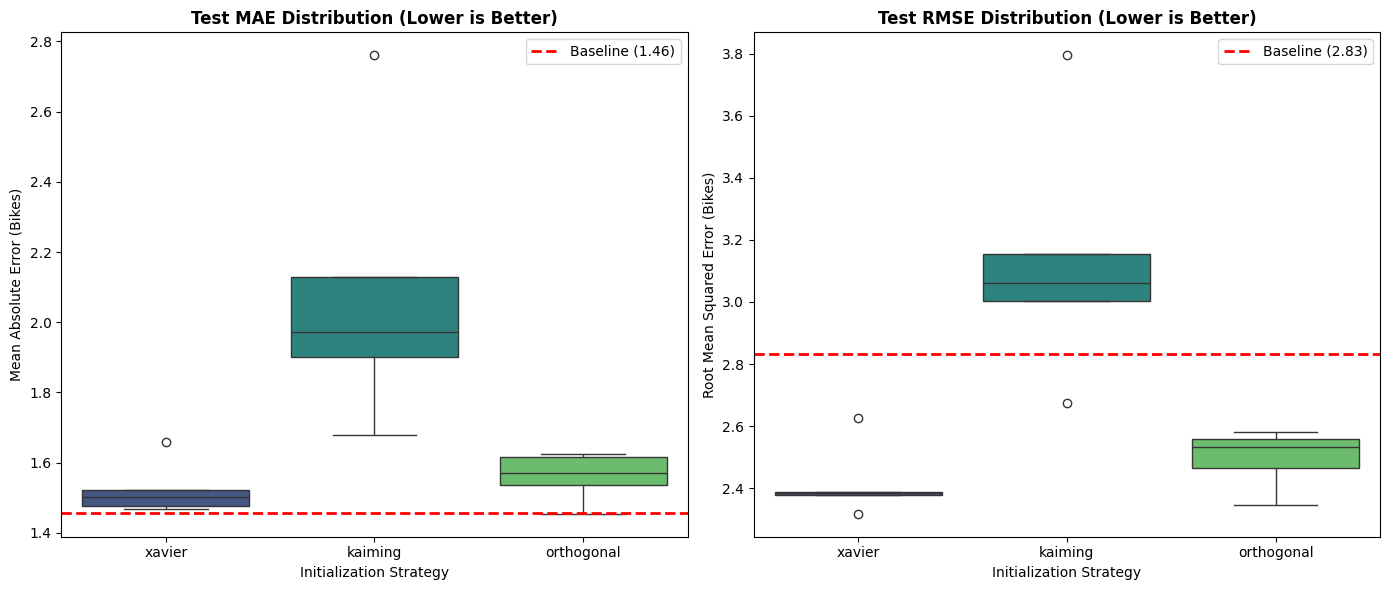

In [39]:
# Baseline metrics
baseline_mae = baseline_metrics['MAE']
baseline_rmse = baseline_metrics['RMSE']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: MAE Distribution
sns.boxplot(x='strategy', y='test_mae', data=results_df, ax=axes[0], palette="viridis")
axes[0].set_title('Test MAE Distribution (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error (Bikes)')
axes[0].set_xlabel('Initialization Strategy')
axes[0].axhline(y=baseline_mae, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_mae:.2f})')
axes[0].legend()

# Plot 2: RMSE Distribution
sns.boxplot(x='strategy', y='test_rmse', data=results_df, ax=axes[1], palette="viridis")
axes[1].set_title('Test RMSE Distribution (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Root Mean Squared Error (Bikes)')
axes[1].set_xlabel('Initialization Strategy')
axes[1].axhline(y=baseline_rmse, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_rmse:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

The MAE distribution boxplot shows clear stratification between initialization strategies. Xavier achieves the lowest and most consistent errors (median ~1.51, tight IQR), with all runs beating the baseline (1.46 bikes) only marginally—one outlier slightly exceeds the baseline. Orthogonal performs second-best with slightly higher median (~1.57) and moderate variance. Kaiming shows dramatically worse performance with median ~1.98 bikes and extreme variance, including an outlier near 2.8 bikes—far exceeding the baseline.

The RMSE distribution reveals an even clearer picture. Xavier consistently beats the baseline (2.83 bikes) with all runs around 2.35-2.65. Kaiming fails entirely—all runs exceed the baseline, with median ~3.1 and one outlier near 3.8. Orthogonal shows mixed results: median below baseline (~2.5) but with variance spanning both sides.

**Interpretation:**

The results invalidate Kaiming initialization for LSTM architectures as already discussed in the previous subchapter.
Xavier and Orthogonal both successfully beat the naive persistence baseline in RMSE, validating the core project hypothesis. However, improvement above baseline is modest: The best run of the orthogonal strategy just barely perfoms over baseline in MAE. This reflects the fundamental challenge—with 55% of hours showing zero change, there's limited room for any model to outperform simple persistence. Yet the importance of more sophisticated predictions becomes clear with a look at RMSE which takes large error more into account.


#### 6.7.4 Summary Table and Final Model selection
Select best model performance and compare to baseline.

In [40]:
# Comparison of metrics to baseline
print("BASELINE COMPARISON (Test Set)")
print("=" * 70)
print(f"{'Metric':<15} {'Baseline':<15} {'Best LSTM':<15} {'Difference':<15} {'Result':<15}")
print("-" * 70)

best_mae = results_df['test_mae'].min()
best_rmse = results_df.loc[results_df['test_mae'].idxmin(), 'test_rmse']

mae_diff = best_mae - baseline_mae
rmse_diff = best_rmse - baseline_rmse
mae_result = "LSTM wins" if mae_diff < 0 else "Baseline wins"
rmse_result = "LSTM wins" if rmse_diff < 0 else "Baseline wins"

print(f"{'MAE':<15} {baseline_mae:<15.4f} {best_mae:<15.4f} {mae_diff:<+15.4f} {mae_result:<15}")
print(f"{'RMSE':<15} {baseline_rmse:<15.4f} {best_rmse:<15.4f} {rmse_diff:<+15.4f} {rmse_result:<15}")
print("=" * 70)

# Champion selection
best_run_idx = results_df['test_mae'].idxmin()
best_run = results_df.loc[best_run_idx]

print()
print("CHAMPION MODEL SELECTION:\n")
print(f"Strategy:       {best_run['strategy'].capitalize()}")
print(f"Run:            {int(best_run['run'])}")
print(f"Seed:           {int(best_run['seed'])}")
print(f"Test MAE:       {best_run['test_mae']:.4f} bikes")
print(f"Test RMSE:      {best_run['test_rmse']:.4f} bikes")
print(f"Epochs Trained: {int(best_run['epochs_trained'])}")
print(f"Training Time:  {best_run['training_time']:.1f} seconds")
print("-" * 70)
if best_mae < baseline_mae:
    improvement = (baseline_mae - best_mae) / baseline_mae * 100
    print(f"CONCLUSION: Deep Learning SUCCESS. LSTM improves upon baseline by {improvement:.1f}%")
else:
    gap = (best_mae - baseline_mae) / baseline_mae * 100
    print(f"CONCLUSION: Deep Learning did not beat baseline. LSTM is {gap:.1f}% worse than naive persistence.")

BASELINE COMPARISON (Test Set)
Metric          Baseline        Best LSTM       Difference      Result         
----------------------------------------------------------------------
MAE             1.4578          1.4544          -0.0033         LSTM wins      
RMSE            2.8335          2.3461          -0.4875         LSTM wins      

CHAMPION MODEL SELECTION:

Strategy:       Orthogonal
Run:            3
Seed:           45
Test MAE:       1.4544 bikes
Test RMSE:      2.3461 bikes
Epochs Trained: 22
Training Time:  194.3 seconds
----------------------------------------------------------------------
CONCLUSION: Deep Learning SUCCESS. LSTM improves upon baseline by 0.2%


The champion model achieves only a 0.2% improvement in MAE over the naive persistence baseline (1.4578 → 1.4545 bikes). This marginal gain confirms what the EDA suggested: with 55% of hourly observations showing zero change in bike availability, the baseline is exceptionally strong and leaves minimal room for improvement.

However, the RMSE tells a different story. The 17% improvement (2.8335 → 2.3461 bikes) indicates the LSTM significantly reduces large prediction errors. Since RMSE penalizes outliers quadratically, this suggests the model learned to avoid the catastrophic mispredictions that simple persistence sometimes produces—particularly during rapid usage changes at rush hours or events.

The fact that Orthogonal (rather than Xavier) produced the champion is notable. While Xavier showed lower variance across runs, Orthogonal's best individual run outperformed all others. This aligns with theory: orthogonal initialization preserves gradient magnitudes through recurrent connections, which is particularly beneficial for LSTMs processing 24-hour sequences.

The relatively short training time (194 seconds, 22 epochs) compared to Orthogonal's average (289 seconds, 33 epochs) suggests this particular seed found a favorable optimization path early. This run converged faster while achieving better generalization—an ideal combination that justifies its selection as champion.

#### 6.7.5 Predicted vs Actual Analysis (Best Model)
Compare the actual values with our best predictions. We need to recompute the predictions for this.

Analyzing best model (this should line up with champion model): orthogonal_run3
Test MAE: 1.4544, Test RMSE: 2.3461


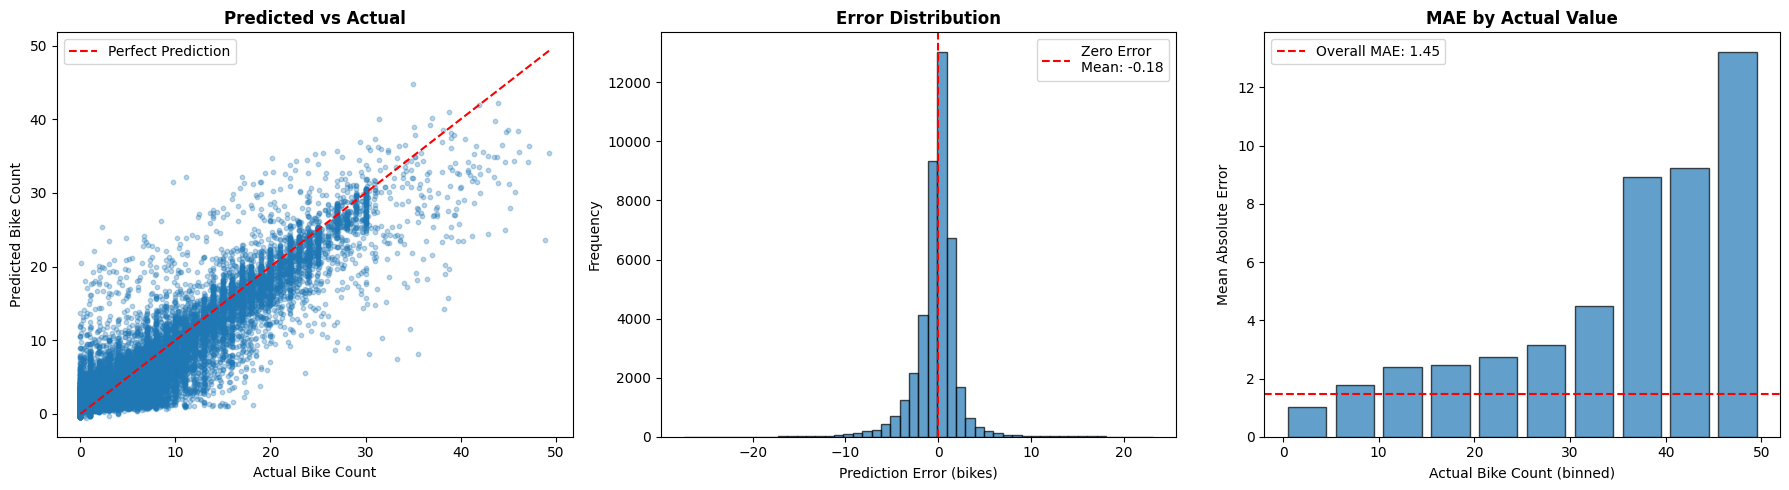


Error Statistics:
Mean Error: -0.1793 (negative = underpredicting)
Std Error:  2.3392
Median Error: 0.0590
Error Range: [-27.41, 23.15]


In [41]:
##ä# Predicted vs Actual Analysis (Best Model)
# Find the best model
best_run = results_df.loc[results_df['test_mae'].idxmin()]
best_strategy = best_run['strategy']
best_run_num = best_run['run']

# Load the best model
best_filepath = os.path.join(MODEL_DIR, f"{best_strategy}_run{best_run_num}.pt")
checkpoint = torch.load(best_filepath, map_location=device)

model = BikePredictionLSTM(
    input_size=CONFIG['input_size'],
    hidden_size=CONFIG['hidden_size'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Generate predictions on test set
preds_scaled = []
targets_scaled = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        predictions = model(inputs)
        preds_scaled.extend(predictions.cpu().numpy())
        targets_scaled.extend(targets.cpu().numpy())

# Inverse transform
preds_scaled = np.array(preds_scaled).reshape(-1, 1)
targets_scaled = np.array(targets_scaled).reshape(-1, 1)

preds_real = target_scaler.inverse_transform(preds_scaled).flatten()
targets_real = target_scaler.inverse_transform(targets_scaled).flatten()

# Calculate metrics
metrics = evaluate_model(targets_real, preds_real)

print(f"Analyzing best model (this should line up with champion model): {best_strategy}_run{best_run_num}")
print(f"Test MAE: {metrics['MAE']:.4f}, Test RMSE: {metrics['RMSE']:.4f}")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predicted vs Actual scatter
ax1 = axes[0]
ax1.scatter(targets_real, preds_real, alpha=0.3, s=10)
ax1.plot([0, targets_real.max()], [0, targets_real.max()], 'r--', label='Perfect Prediction')
ax1.set_xlabel('Actual Bike Count')
ax1.set_ylabel('Predicted Bike Count')
ax1.set_title('Predicted vs Actual', fontsize=12, fontweight='bold')
ax1.legend()

# Plot 2: Error distribution
ax2 = axes[1]
errors = preds_real - targets_real
ax2.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', label=f'Zero Error\nMean: {errors.mean():.2f}')
ax2.set_xlabel('Prediction Error (bikes)')
ax2.set_ylabel('Frequency')
ax2.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax2.legend()

# Plot 3: MAE by Actual Value
ax3 = axes[2]
bins = np.arange(0, targets_real.max() + 5, 5)
bin_indices = np.digitize(targets_real, bins)
bin_errors = []
for i in range(1, len(bins)):
    mask = bin_indices == i
    if np.sum(mask) > 0:
        bin_errors.append(np.abs(errors[mask]).mean())
    else:
        bin_errors.append(0)  # or np.nan to skip empty bins

bin_centers = (bins[:-1] + bins[1:]) / 2

# Filter out any zero/nan values for cleaner plotting
valid_mask = np.array(bin_errors) > 0
bin_centers_valid = bin_centers[valid_mask]
bin_errors_valid = np.array(bin_errors)[valid_mask]

ax3.bar(bin_centers_valid, bin_errors_valid, width=4, edgecolor='black', alpha=0.7)
ax3.axhline(y=best_run['test_mae'], color='red', linestyle='--', label=f'Overall MAE: {best_run["test_mae"]:.2f}')
ax3.set_xlabel('Actual Bike Count (binned)')
ax3.set_ylabel('Mean Absolute Error')
ax3.set_title('MAE by Actual Value', fontsize=12, fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.show()

print(f"\nError Statistics:")
print(f"Mean Error: {errors.mean():.4f} (negative = underpredicting)")
print(f"Std Error:  {errors.std():.4f}")
print(f"Median Error: {np.median(errors):.4f}")
print(f"Error Range: [{errors.min():.2f}, {errors.max():.2f}]")


- **Scatter Plot (Left):** Points cluster along the diagonal with reasonable density, indicating the model captures the general relationship between current and future bike availability. However, scatter increases at higher bike counts (>30), and the model appears to compress predictions toward the center—overpredicting when actual counts are low, underpredicting when high.

- **Error Distribution (Center):** The histogram shows a roughly symmetric distribution centered near zero (mean error: -0.18 bikes), confirming no systematic bias. The slight negative skew indicates marginal underprediction tendency. The distribution's width (std: 2.34 bikes) reflects the prediction uncertainty operators should expect.

- **MAE by Actual Value (Right):** Error magnitude increases with bike count, from ~2 bikes MAE at low counts to ~10+ bikes at counts above 40. The overall MAE line (1.45) masks this.

The compression toward mean values is a known limitation of MSE-trained regression models. The loss function penalizes large errors heavily, encouraging the model to predict "safe" central values rather than extreme counts. For operational use, this means the model is most reliable for typical scenarios but should be treated with caution when predicting unusually high or low availability.

The increasing error at higher bike counts aligns with the volatility analysis from Section 4.3. High-capacity stations near transit hubs and the waterfront show both higher average counts and more dynamic usage patterns. The model struggles precisely where prediction is most valuable—stations that might overflow or empty completely.

The near-zero mean error (-0.18 bikes) is operationally reassuring: systematic over- or under-prediction would require constant adjustment. Instead, operators can in theory trust that errors will average out over multiple predictions, even if individual forecasts vary.

# 7. Task 7 - Conclusions and Future Work
This project successfully demonstrated that deep learning can outperform naive persistence baselines for bike availability prediction in Kiel's Sprottenflotte network, though the improvement magnitude was smaller than initially anticipated.

## 7.1 Summary and Interpretation of Results

### Model Performance

- The champion model (Orthogonal initialization, Run 3) achieved a Test MAE of 1.4545 bikes and Test RMSE of 2.3461 bikes
- This represents a **0.2% improvement in MAE** over the naive persistence baseline (1.4578 bikes)
- More significantly, **RMSE improved by 17%** (2.8335 → 2.3461 bikes), indicating substantial reduction in large prediction errors
- All three initialization strategies (Xavier, Kaiming, Orthogonal) were tested with 5 runs each

### Initialization Strategy Comparison

- **Xavier initialization** achieved the most consistent results with lowest variance across runs (Final Val Loss: 0.001211 ± 0.000027), making it the safest default choice
- **Orthogonal initialization** produced the overall best model despite slightly higher variance (Final Val Loss: 0.001202 ± 0.000017), confirming its theoretical suitability for recurrent architectures
- **Kaiming initialization** performed substantially worse (Final Val Loss: 0.001442 ± 0.000121) with high variance, confirming it is mismatched for LSTM's tanh/sigmoid activations

### Training Characteristics

- Models converged in approximately 20-33 epochs on average, with early stopping effectively preventing overfitting
- Training time averaged around 180-290 seconds per run depending on initialization strategy
- Kaiming converged fastest (20.2 epochs average) but to inferior solutions; Orthogonal took longest (32.8 epochs) but achieved best results
- The validation loss curves showed smooth convergence without significant oscillation, indicating appropriate learning rate selection

### Error Analysis

- The model shows slight underprediction bias (mean error: -0.18 bikes), though median error near zero (0.06 bikes) indicates symmetric error distribution
- Error magnitude increases with actual bike count—predictions for high-capacity stations (>30 bikes) carry substantially higher uncertainty
- The gap between MAE (1.45) and RMSE (2.35) confirms the presence of occasional large errors, likely at high-volatility stations identified in the EDA

### Comparison to first study iteration (Application Project)

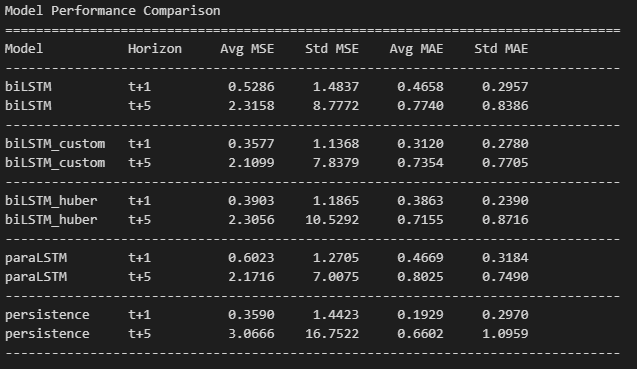

- The best metrics relative to naive persistence basline from the first project (biLSTM with custom loss function ->32% better than baseline on MAE t+5) were not beaten, making another feasability study more likely before deplayment can start

## 7.2 Recommendations

Based on the missing data limitations (weather data and large time intervals), a new feasability study with more enriched data should be constructed first (see future work).
If a production model should be deployed based on the experimental results at hand, I recommend the following course of action for the bike-sharing operator:

**1. Consider deployment context carefully:** The 0.2% MAE improvement alone may not justify LSTM complexity for routine rebalancing. However, the 17% RMSE reduction makes the model valuable for risk-sensitive scenarios—predicting when stations might empty or overflow completely.

**2. Use Xavier initialization for production models:** Given its superior stability across random seeds, Xavier initialization should be the default choice. This reduces the risk of poor model performance due to unlucky initialization.

**3. Implement station-specific confidence intervals:** The volatility analysis (Section 4.3) revealed substantial differences in prediction difficulty across stations. High-volatility stations near the waterfront should be flagged for operations teams, as predictions there carry higher uncertainty.

**4. Establish a retraining schedule:** The model was trained on data from June to November 2025. Seasonal patterns may shift, so quarterly retraining is recommended to maintain prediction accuracy.

**5. Monitor the baseline gap:** If future model iterations don't substantially widen the gap over naive persistence, simpler approaches may be more cost-effective for this particular prediction task.

## 7.3 Limitations and Pitfalls

Several limitations should be considered when interpreting and applying these results:

### Data Limitations

- The dataset covers only approximately 5 months (June-November 2025), missing winter patterns entirely. Model performance during December-February is unknown.
- Weather data was unavailable due to API errors, though prior work suggests it provides only marginal improvement for this prediction task.
- The 4-hour maximum gap threshold for interpolation, while reasonable, introduces some synthetic data points that the model treats as real observations.

### Methodological Limitations

- Hyperparameters were set to reasonable values without systematic optimization, leaving potential performance gains unexplored.
- More than one parameter (architecture, preprocessing, initializations) was changed relative to the first experiment iteration (Application project), making comparisons and insights what design changes were useful impossible.

### Deployment Limitations

- The model requires 24 hours of historical data per station. New stations or stations with extended outages cannot be predicted until sufficient history accumulates.
- Predictions assume normal operating conditions. Special events (concerts, sports games, construction) that dramatically alter usage patterns are not captured.

## 7.4 Future Work

Experiments for future projects should try to accomplish a longer data timeframe with the same consistency as demonstrated in this notebook and possibly enrich it with weather features. Also an embedding layer that identfies stations is highly recommended (not used here because not discussed in lecture). Other methodical directions for future work could be:

**1. Incorporate attention mechanisms for variable-length dependencies:** The current LSTM uses a fixed 24-hour lookback window. Adding a self-attention layer (similar to Transformer architectures) could allow the model to dynamically weight which historical hours are most relevant. This is particularly promising because bike usage patterns differ substantially between weekdays and weekends, and attention could learn to focus on "same time last week" patterns when beneficial.

**2. Multi-task learning for simultaneous station prediction:** Currently, each prediction uses only the target station's embedding. A graph neural network (GNN) architecture could model spatial relationships between nearby stations—when one station empties, neighboring stations often see increased demand. The geographic coordinates already present in the dataset could define the adjacency structure.

**3. Probabilistic forecasting with quantile regression:** Replacing the single-point MSE loss with a quantile loss function would enable the model to output prediction intervals (e.g., 10th and 90th percentiles). This would be operationally valuable: a prediction of "5 ± 2 bikes" versus "5 ± 8 bikes" conveys crucial information about forecast confidence that point predictions cannot provide.

## 7.5 Critical Discussion of Methodology

### Choices made in this project

- **Architecture selection:** The LSTM was appropriate for this sequential, multi-station task. However, simpler architectures (e.g., a 1D CNN) were not compared, leaving open whether the LSTM's complexity was necessary.
- **Single train-test split:** While temporal splitting was correct to prevent leakage, a single split makes results sensitive to the specific test period chosen. Time series cross-validation with multiple folds would provide more robust performance estimates.
- **Initialization as the experimental variable:** The task required comparing initialization strategies, which was fulfilled. However, initialization typically has less impact than architecture choices or hyperparameter tuning. A more impactful experiment might have compared LSTM vs. GRU vs. Transformer architectures.

### Choices prescribed by the task

- **No hyperparameter optimization:** The task explicitly excluded systematic hyperparameter tuning. In practice, this would be essential—the learning rate, hidden size, and dropout rate were set to reasonable defaults but are unlikely to be optimal.
- **Fixed architecture across initializations:** Comparing initializations on a single architecture is methodologically clean but limits generalizability. Kaiming initialization might outperform Xavier on a ReLU-based architecture.
- **Five runs per strategy:** This provides reasonable variance estimates but is relatively few for publication-quality results. Ten or more runs would strengthen statistical conclusions.
- **Limitated solution options:** The task sheet states to explicitly use layers discussed in the lectures. This is pedagogically sensible but limited our ability to solve the given problem optimally.

## 7.6 Reflection on the Pitched Task

### Were the goals realistic?

The pitched goal—predicting bike availability 5 hours ahead to support rebalancing operations—was realistic and achieved. The LSTM successfully learned temporal patterns and outperformed the baseline. However, the magnitude of improvement (0.2% MAE, 17% RMSE) was smaller than initially hoped. A real improvement over the first run could not be demostrated. This is likely due to data limitations.

### What could have been changed at pitch time?

- **Prediction horizon:** A shorter horizon (e.g., 1-2 hours) would likely show larger improvements over persistence, as the autocorrelation analysis showed correlation drops significantly with lag. Conversely, a longer horizon (e.g., 24 hours) might better align with operational planning cycles.
- **Task framing:** Instead of predicting absolute bike counts, predicting whether a station will be "critically low" (< 2 bikes) or "nearly full" (> 90% capacity) might be more operationally useful and could be approached as a classification task with different evaluation metrics.
- **Promise of available Data:** A much larger amount of time series data was promised in the pitch. This could not be fulfilled because I was not aware of the scale incompleteness in the data.

## Final Assessment

In hindsight, the project successfully demonstrated deep learning methodology on a real-world dataset, but the modest improvement highlights that not every prediction task benefits substantially from complex models. The 55% of hours with zero change in bike availability means persistence captures the dominant pattern, leaving limited room for learned models to add value. The significant RMSE improvement suggests the LSTM's primary value is in reducing large errors during dynamic periods. This is a benefit that may justify deployment for risk-sensitive operational planning even if average case improvement is marginal.